# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [94]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

# %matplotlib inline

In [95]:
%load_ext autoreload
%autoreload 2

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection
from parsers.diann.diann_plotting import *

from parsers.bps.bps_loader import BPSLoader
from parsers.bps.bps_collection import BPSCollection
from parsers.bps.bps_plotting import *

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

from plotting.dash import DashPlots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [7]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

## Base

In [8]:
source = 'base'

In [9]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

In [10]:
lccollection = VNeoMethodCollection()
lccollection.add_methods_from_folder(f'/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/methods/LC/VNTT_260428')

Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]'],
      dtype='object')


(<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Value'>,
 <Axes: ylabel='Neo.PumpModule.Pump.Flow.Nominal [µl/min]'>)

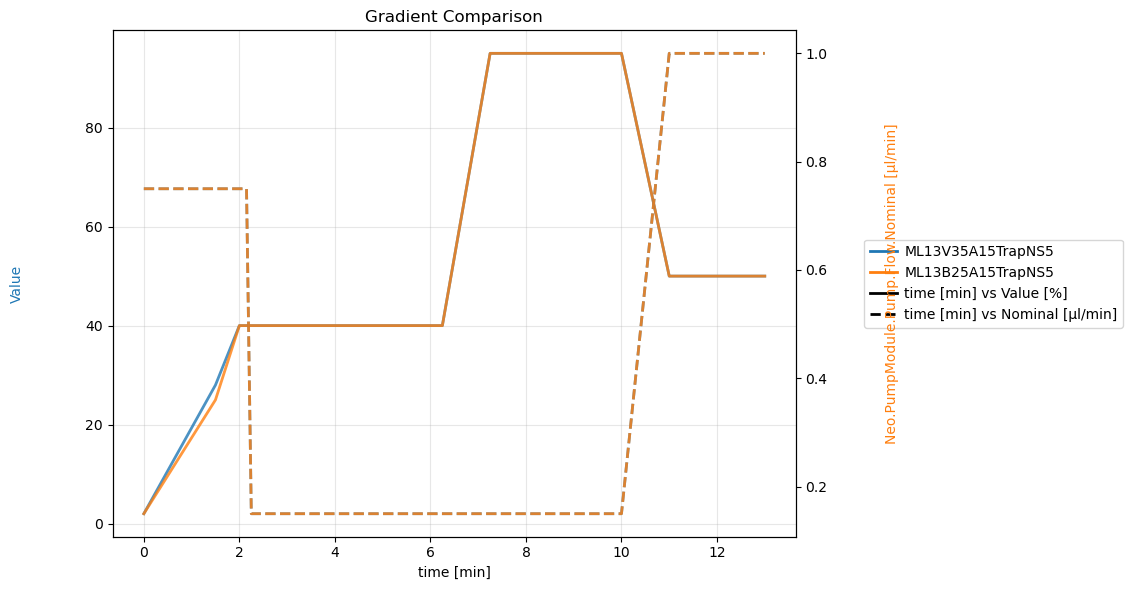

In [11]:
lccollection.plot_gradients(method_names = ['ML13V35A15TrapNS5', 'ML13B25A15TrapNS5'], x_cols='time [min]', y_cols = ['Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], twin_axes=True)

In [371]:
# Collect all FWHM data for combined plotting
all_fwhm_data = []
method_labels = []

for _, row in variablewindows100ms.iterrows():
    samples = row['sample_name']
    method_label = f"{row['MSmeth']} {row['LCmeth']}"
    
    # Check if samples exist in var_names
    mask = spnt_collection['peptide'].var_names.isin(samples)
    
    if not mask.any():
        print(f"No matching samples found for {method_label}")
        continue
        
    temp = spnt_collection['peptide'].layers['precursor_fwhm'][:, mask]
    
    if temp.size == 0:
        print(f"Empty data for {method_label}")
        continue
    
    # Calculate average FWHM for each observation
    avg_fwhm = pd.DataFrame(temp).apply(lambda x: np.nanmean(x) if not np.all(x.isna()) else np.nan, axis=1) * 60
    
    # Remove NaN values
    valid_fwhm = avg_fwhm.dropna()
    
    if len(valid_fwhm) == 0:
        print(f"No valid FWHM data for {method_label}")
        continue
    
    # Add to combined data
    all_fwhm_data.extend(valid_fwhm.tolist())
    method_labels.extend([method_label] * len(valid_fwhm))

# Create combined dataframe and plot
if all_fwhm_data:
    combined_df = pd.DataFrame({
        'FWHM': all_fwhm_data,
        'Method': method_labels
    })
    
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=combined_df, x='Method', y='FWHM')
    plt.xticks(np.arange(0, 50, 2), rotation=45, ha='right')
    plt.ylabel('FWHM (seconds)')
    plt.title('FWHM Distribution by Method Combination')
    plt.tight_layout()
    plt.show()
else:
    print("No valid FWHM data found for any method combination")

NameError: name 'variablewindows100ms' is not defined

<Axes: ylabel='Count'>

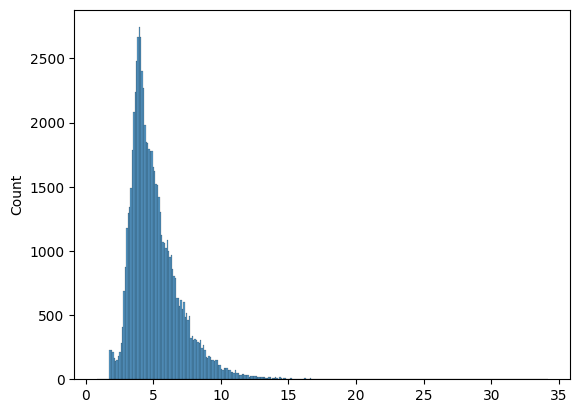

In [ ]:
sns.histplot(60 * (test['rt_end'] - test['rt_start']))

## MS Methods

### Load MS Methods

In [96]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [97]:
mscollection.add_methods_from_folder(f"/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/methods/MS/VNTT_260428.zip")
msmethod_names = '\n'.join(mscollection.methods.keys())

In [168]:
ML20 = lccollection.methods['20m150nlML30mA15phospho4'].copy()
ML20.adjusted_elution(in_place=True, dead_time = 5.5)

In [ ]:
ML20
sns

Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]'],
      dtype='object')


(<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Value'>,
 <Axes: ylabel='Neo.PumpModule.Pump.%B.Value [%]'>)

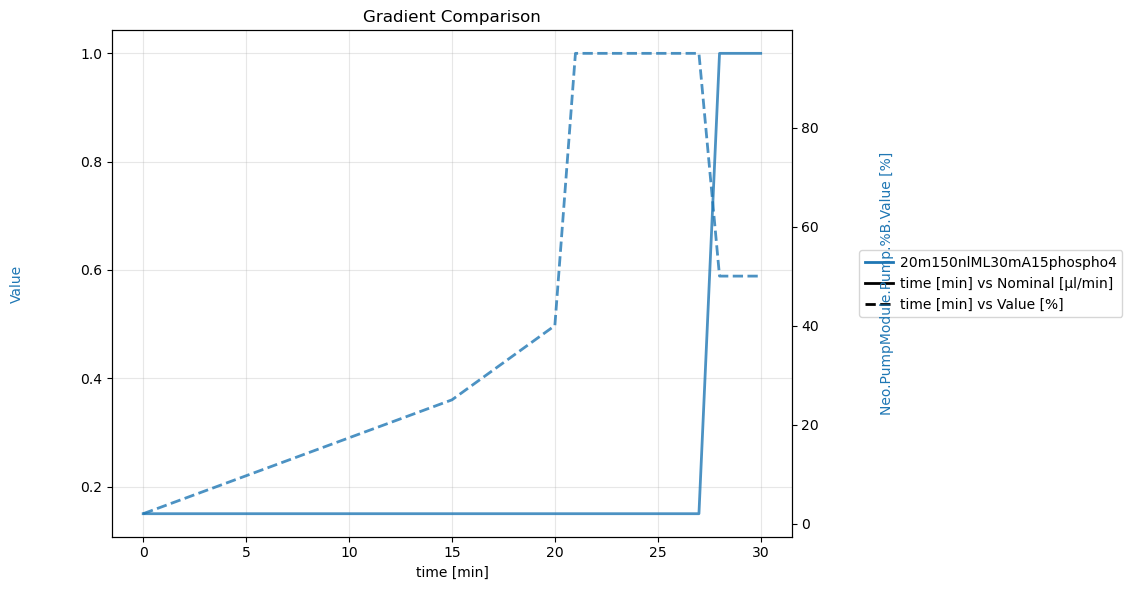

In [146]:
lccollection.plot_gradients('20m150nlML30mA15phospho4', twin_axes=True)


In [165]:
dn_collection['precursor'].var

,File.Name,Run,search_type,hystar_index
File.Name,,,,
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V35A15TrapNS5_012951_VNTT006_timsTOF_B-H2_1_15724,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,analysis,bps_diann,15724
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012915_VNTT006_timsTOF_B-H2_1_15708,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15708
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012911_VNTT006_timsTOF_B-H2_1_15704,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,analysis,bps_diann,15704
HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012652_VNTT001_timsTOF_G-H1_1_15509,HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15...,analysis,bps_diann,15509
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012913_VNTT006_timsTOF_B-H2_1_15706,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15706
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V35A15TrapNS5_012950_VNTT006_timsTOF_B-H2_1_15723,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V...,analysis,bps_diann,15723
HeLaI5ng_Ddil_F1_R1_T1_DIA003V1300-ML13V35A15TrapNS5_012931_VNTT006_timsTOF_B-H2_1_15716,HeLaI5ng_Ddil_F1_R1_T1_DIA003V1300-ML13V35A15T...,analysis,bps_diann,15716
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V35A15TrapNS5_012957_VNTT006_timsTOF_B-H2_1_15730,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V...,analysis,bps_diann,15730
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V...,analysis,bps_diann,15732


In [170]:
ML20.gradient

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Neo.PumpModule.Pump.StartColumnWash,length [min],volume (nL),total volume (nL),Dead Volume Used (nL),Total + Dead Volume (nL),Trapped %B Contribution,Actual Time to Elute Nominal %B (min),Base Actual %B,Actual %B
0,0.0,0.15,2.0,5,NaN,0.0,0.0,0.0,825.0,825.0,0.0,5.500,2.000000,2.000000
1,15.0,0.15,25.0,5,NaN,15.0,2250.0,2250.0,825.0,3075.0,0.0,20.500,16.566667,16.566667
2,20.0,0.15,40.0,5,1.0,5.0,750.0,3000.0,825.0,3825.0,0.0,25.500,24.233333,24.233333
3,21.0,0.15,95.0,5,NaN,1.0,150.0,3150.0,825.0,3975.0,0.0,26.500,26.500000,26.500000
4,27.0,0.15,95.0,5,NaN,6.0,900.0,4050.0,825.0,4875.0,0.0,27.825,95.000000,95.000000
5,28.0,1.00,50.0,5,NaN,1.0,1000.0,5050.0,825.0,5875.0,0.0,28.825,87.125000,87.125000
6,30.0,1.00,50.0,5,NaN,2.0,2000.0,7050.0,825.0,7875.0,0.0,30.000,50.000000,50.000000


Text(0.5, 1.0, 'Precursor Elution Profile Delay-Corrected Gradient')

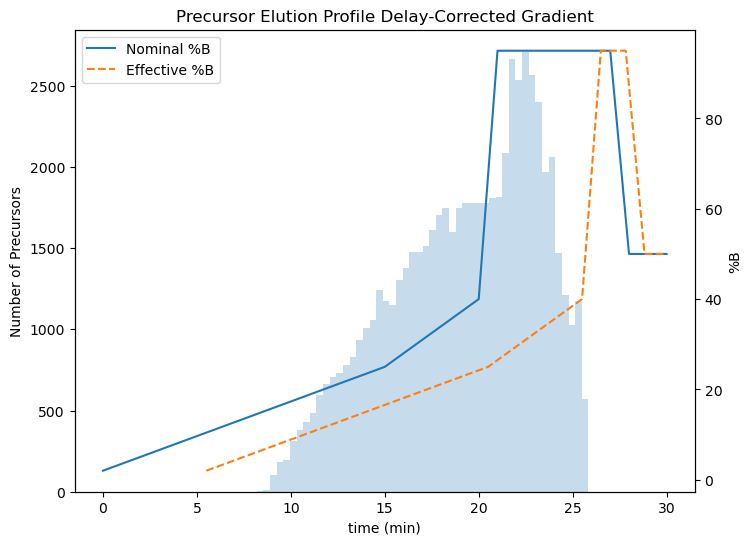

In [204]:
sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012656_VNTT001_timsTOF_G-H1_1_15513']
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(sample.layers['RT'], bins=50, ax=ax, edgecolor=None, alpha=0.25, legend=False)
ax2 = ax.twinx()
sns.lineplot(data = ML20.gradient, x='time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax2, label='Nominal %B')
sns.lineplot(data = ML20.gradient, x='Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax2, linestyle='--', label='Effective %B')

ax.set_ylabel('Number of Precursors')
ax.set_xlabel('time (min)')
ax2.set_ylabel('%B')
ax.set_title('Precursor Elution Profile Delay-Corrected Gradient')

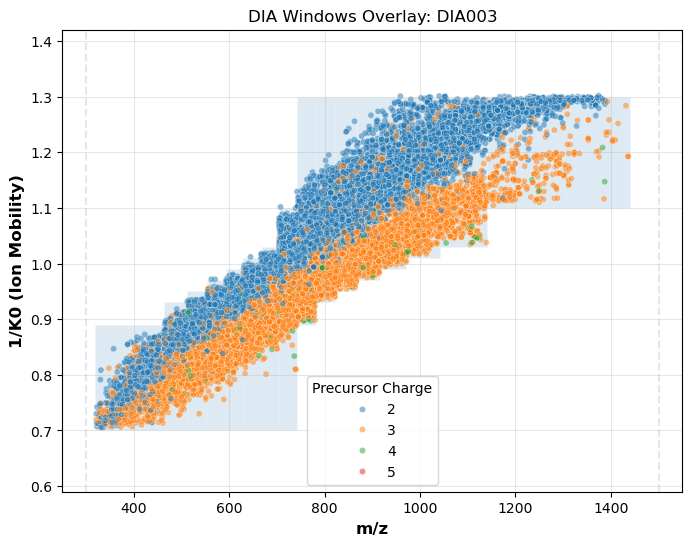

In [142]:
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10')


ax.legend(title='Precursor Charge')


# Legend Removal Options

Here are different ways to handle the legend in your plot:

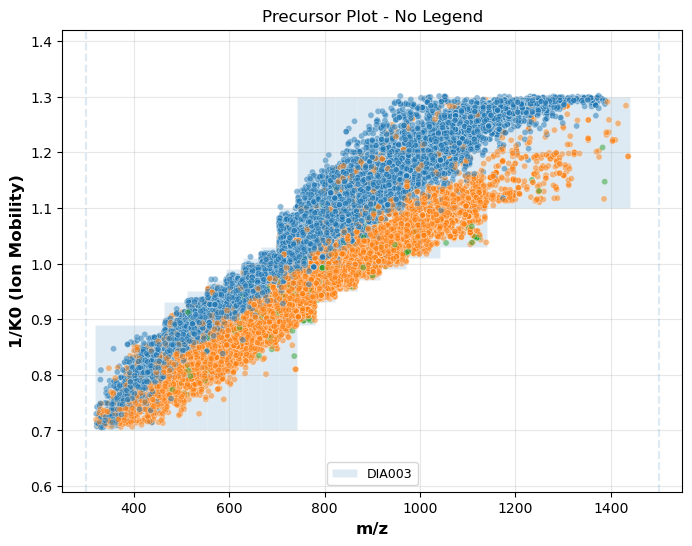

In [197]:
# Option 1: Remove legend completely using legend=False in seaborn
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10', legend=False)

ax.set_title('Precursor Plot - No Legend')
plt.show()

In [ ]:
# Option 2: Remove legend after creating the plot
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10')

# Remove the legend
ax.get_legend().remove()

ax.set_title('Precursor Plot - Legend Removed After')
plt.show()

In [ ]:
# Option 3: Move legend to a different position instead of removing
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10')

# Move legend to different location - try 'lower left', 'lower right', 'center left', 'outside'
ax.legend(title='Precursor Charge', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title('Precursor Plot - Legend Outside')
plt.tight_layout()
plt.show()

In [ ]:
# Option 4: Keep legend but make it smaller and less prominent  
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10')

# Customize legend: smaller font, no frame, transparent background
ax.legend(title='Precursor Charge', fontsize='small', title_fontsize='small', 
         frameon=False, facecolor='none', loc='upper right')

ax.set_title('Precursor Plot - Small Legend')
plt.show()

# Quick fixes for your original plot

If you just want to fix your original plot, here are the simplest solutions:

In [ ]:
# Simply add legend=False to your seaborn plot - easiest fix!
fig, ax = plt.subplots(figsize=(8, 6))

sample = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

mscollection.plot_windows(['DIA003'], ax = ax, alpha=0.15)
# Just add legend=False here ↓
sns.scatterplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), y=sample.layers['Exp.1/K0'].flatten(), ax=ax, s=20, alpha=0.5, hue = sample.obs['Precursor.Charge'], palette='tab10', legend=False)

# Remove or comment out this line:
# ax.legend(title='Precursor Charge')

Text(0.5, 1.0, 'dia-PASEF Window Comparison')

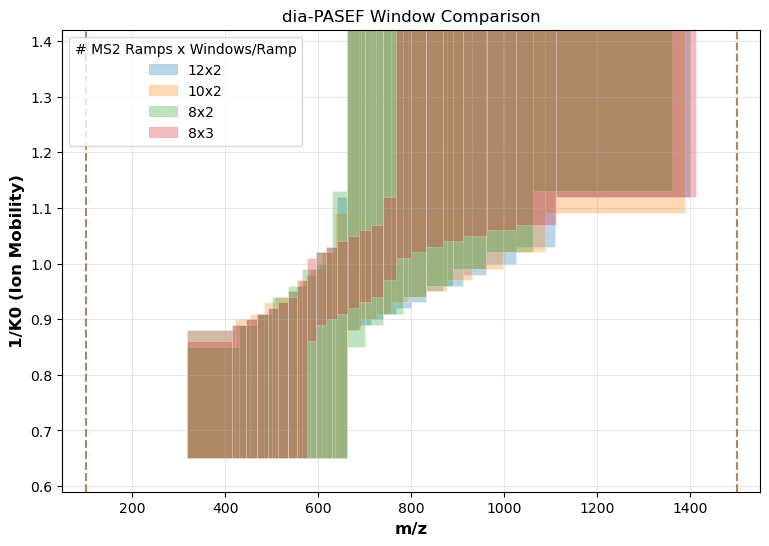

In [424]:
fig, ax = plt.subplots(figsize=(9, 6))
mscollection.plot_windows(['DIA100msW122V1300', 'DIA100msW102V1300', 'DIA100msW82V1300', 'DIA100msW83V1300'], alpha=0.3, ax=ax)

# Get tab10 colors for the legend
tab10_colors = plt.cm.tab10(range(4))
legend = ax.legend(['12x2', '10x2', '8x2', '8x3'], title='# MS2 Ramps x Windows/Ramp')
for i, legend_handle in enumerate(legend.legend_handles):
    legend_handle.set_color(tab10_colors[i])

ax.set_title('dia-PASEF Window Comparison')

### BPS

In [11]:
spnt_collection = BPSCollection(search_type='bps_spectronaut')

In [491]:
# spnt_collection.add_searches('/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/Spectronaut/artifact-export(3)', 
#                              levels=['peptide'])

In [ ]:
pd.read_parquet('/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/Spectronaut/artifact-export(3)/processing-runs/2bf9f1e4-f965-472c-a542-b43955161bbb/p8s/spectronaut-id.protein.parquet')

,protein_group_id,processing_run_uuid,sample_name,protein_group_name,protein_accession,protein_name,gene_id,pg_quantity,pg_q_value,number_precursors,number_peptides,number_stripped_peptides,pg_quantity_ms1,pg_quantity_ms2,pg_cv,pg_q_value_run_wise,organisms,protein_description
0,0,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,A0A024RBG1;Q9NZJ9-2,A0A024RBG1;Q9NZJ9-2,NUD4B_HUMAN;NUDT4_HUMAN,NUDT4B;NUDT4,NaN,1.346319e-05,3,3,3,NaN,NaN,NaN,1.575673e-07,Homo sapiens,Diphosphoinositol polyphosphate phosphohydrola...
1,1,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,A0A0B4J2D5;P0DPI2,A0A0B4J2D5;P0DPI2,GAL3B_HUMAN;GAL3A_HUMAN,GATD3B;GATD3A,NaN,3.439071e-49,7,6,6,NaN,NaN,NaN,3.505915e-10,Homo sapiens,Glutamine amidotransferase-like class 1 domain...
2,2,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,A0A0B4J2F0,A0A0B4J2F0,PIOS1_HUMAN,PIGBOS1,437.764252,8.520161e-50,2,2,1,1027.287598,437.764252,NaN,8.309184e-12,Homo sapiens,Protein PIGBOS1
3,3,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,A0A0U1RR11;A0A0U1RRI6;P0DPI3,A0A0U1RR11;A0A0U1RRI6;P0DPI3,CENL1_HUMAN;CENL3_HUMAN;CENL2_HUMAN,CENPVL1;CENPVL3;CENPVL2,NaN,1.448448e-05,1,1,1,NaN,NaN,NaN,3.362555e-09,Homo sapiens,Centromere protein V-like protein 1;Centromere...
4,4,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,A0A140G945;A0A140G945-2;P02489,A0A140G945;A0A140G945-2;P02489,CRYA2_HUMAN;CRYA2_HUMAN;CRYAA_HUMAN,CRYAA2;CRYAA2;CRYAA,NaN,2.217675e-04,1,1,1,NaN,NaN,NaN,4.071763e-07,Homo sapiens,Alpha-crystallin A2 chain;Isoform 2 of Alpha-c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518,6518,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,Q9Y6W5,Q9Y6W5,WASF2_HUMAN,WASF2,405.000336,1.144741e-05,3,3,3,645.822510,405.000336,NaN,4.289837e-09,Homo sapiens,Wiskott-Aldrich syndrome protein family member 2
6519,6519,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,Q9Y6X3,Q9Y6X3,SCC4_HUMAN,MAU2,112.108925,1.513858e-05,3,3,3,448.696716,112.108925,NaN,1.575673e-07,Homo sapiens,MAU2 chromatid cohesion factor homolog
6520,6520,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,Q9Y6X9;Q9Y6X9-2,Q9Y6X9;Q9Y6X9-2,MORC2_HUMAN,MORC2,NaN,3.240413e-12,12,12,12,NaN,NaN,NaN,1.575673e-07,Homo sapiens,ATPase MORC2;Isoform 2 of ATPase MORC2
6521,6521,2bf9f1e4-f965-472c-a542-b43955161bbb,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,Q9Y6Y0,Q9Y6Y0,NS1BP_HUMAN,IVNS1ABP,250.921494,1.698150e-46,7,7,6,369.354401,250.921494,NaN,1.575673e-07,Homo sapiens,Influenza virus NS1A-binding protein


In [12]:
spnt_collection.add_searches('/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/Spectronaut/artifact-export(3)', 
                             levels=['peptide','protein'])

Filtering Spectronaut files for levels: ['peptide', 'protein']
Found 25 peptide parquet files
Found 25 protein parquet files
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronaut-id.peptide.parquet
Loaded peptide data from spectronau

In [102]:
dn_collection = BPSCollection(search_type='bps_diann')

In [103]:
dn_collection.add_searches('/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/BPS/vntt_diann.zip')

Found 27 tims-diann.result.zip files

📊 Summary: Found 27 total samples
   UUIDs/samples: ['707c9499-b803-4a5c-8f90-b9ca8ce9559b', 'fff3a33f-37bc-43e9-ab24-c8a31e392c46', '8fe5e8d6-8b18-4ddd-8d0a-7b3ed41e8dab', 'fdadcff9-58cb-4cfc-b347-86847367d168', '54220d9f-402c-4826-adaf-c1921c50f83f', 'd3c78a16-f0b3-4f09-86e2-23f80b65446f', 'b7010849-a78b-483e-9e06-fd8f2365ebc7', '1dcd5221-612f-4095-b446-6b2d80f635ee', '2e8b2629-349d-4627-b8df-1ad8b1b78788', '675e14ba-095e-4557-9220-8bfe8584b5a8', 'd12a9398-8f25-4632-943f-06d9b3c0cda9', '08faa1cd-b2fa-4959-b2aa-f2911713668c', '08471bb9-bae4-42be-b65a-9c8f7ff2b406', 'e14d9354-2c91-4bbc-ac5f-13c8080fb178', '01898f9f-03c5-4fbe-98e3-00858373442a', 'ac19d26c-cca2-4440-8fba-f95e45d3b79e', '1f93788d-ba96-4eb4-b297-624d0ac0ea19', '8fcff1e0-9ebd-4de6-b8a4-9d1d3a5305bb', '6d3e0469-f881-4611-a6e0-25d60d828ba0', 'e687a722-ee82-45d8-a413-2266014c4c5e', 'a770027c-f94f-456c-8346-1cbdcb77d4f4', 'c73b797b-ffba-443f-91b6-2a8cfd02393e', 'd6b3f6d1-ceee-4f13-99dc-58c8

In [110]:
dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012654_VNTT001_timsTOF_G-H1_1_15511']

View of AnnData object with n_obs × n_vars = 117848 × 1
    obs: 'Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'obs_unique'
    var: 'File.Name', 'Run', 'search_type', 'hystar_index'
    layers: 'Precursor.Normalised', 'Precursor.Quantity', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info', 'Precursor.FWHM', 'Precursor.Error.Ppm', 'Corr.Precursor.Error.Ppm', 'Data.Points', 'Ms1.Iso.Corr.Sum', 'Library.Precursor.Mz', 'Corrected.Precursor.Mz', 'Precursor.Calibrated.Mz', 'Fragment.Calibrated.Mz', 'Exp.1/K0', 'Lib.1/K0'

In [ ]:
# spnt_collection.save(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/poster_vntt_spntcollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/poster_vntt_spntcollection.pkl


In [ ]:
# spnt_collection = BPSCollection.from_file(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/poster_vntt_spntcollection.pkl', search_type='bps_spectronaut')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/poster_vntt_spntcollection.pkl


In [ ]:
map_lcms_methods(dn_collection, ['/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT001_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT003_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT006_combined.csv'])

,File Name,Path,Instrument Method,Position,Inj Vol,Sample ID,MS Method,Result Path,lc meth,sample,ms meth
0,Wash1_012616_VNTT001_timsTOF,E:\Data\2026_04\VNTT001\Wash,D:\Methods\VNeo\A15\Wash\Blank7m650nlML11mA15,G:A4,2.0,Wash1_012616_VNTT001_timsTOF,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Wash\Wash1_012616_VNTT...,Blank7m650nlML11mA15,Wash1_012616_VNTT001_timsTOF_G-A4_1_15455,DIA003
1,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
2,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
3,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
4,Wash1_012623_VNTT001_timsTOF,E:\Data\2026_04\VNTT001\Wash,D:\Methods\VNeo\A15\Wash\Blank7m650nlML11mA15,G:A4,2.0,Wash1_012623_VNTT001_timsTOF,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Wash\Wash1_012623_VNTT...,Blank7m650nlML11mA15,Wash1_012623_VNTT001_timsTOF_G-A4_1_15459,DIA003
...,...,...,...,...,...,...,...,...,...,...,...
164,HeLaI5ng_Ddil_F1_R7_T1_DIA80msW122V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW1...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R7_T1_DIA80msW122V1300-ML13V3...,DIA80msW122V1300
165,HeLaI5ng_Ddil_F1_R17_T1_DIA80msW82V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW8...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R17_T1_DIA80msW82V1300-ML13V3...,DIA80msW82V1300
166,HeLaI5ng_Ddil_F1_R16_T1_DIA80msW82V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW8...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R16_T1_DIA80msW82V1300-ML13V3...,DIA80msW82V1300
167,HeLaI5ng_Ddil_F1_R12_T1_DIA80msW102V1300-ML13V...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW1...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R12_T1_DIA80msW102V1300-ML13V...,DIA80msW102V1300


In [13]:
map_lcms_methods(spnt_collection, ['/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT001_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT003_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT006_combined.csv'])

,File Name,Path,Instrument Method,Position,Inj Vol,Sample ID,MS Method,Result Path,lc meth,sample_name,ms meth
0,Wash1_012616_VNTT001_timsTOF,E:\Data\2026_04\VNTT001\Wash,D:\Methods\VNeo\A15\Wash\Blank7m650nlML11mA15,G:A4,2.0,Wash1_012616_VNTT001_timsTOF,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Wash\Wash1_012616_VNTT...,Blank7m650nlML11mA15,Wash1_012616_VNTT001_timsTOF_G-A4_1_15455,DIA003
1,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
2,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
3,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,E:\Data\2026_04\VNTT001\Data,D:\Methods\VNeo\A15\Separation\phospho\20m150n...,G:A2,1.0,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Data\BSAI3fmol_Ddil_F1...,20m150nlML30mA15phospho4,BSAI3fmol_Ddil_F1_R1_T1_DIA003-20m150nlML30mA1...,DIA003
4,Wash1_012623_VNTT001_timsTOF,E:\Data\2026_04\VNTT001\Wash,D:\Methods\VNeo\A15\Wash\Blank7m650nlML11mA15,G:A4,2.0,Wash1_012623_VNTT001_timsTOF,D:\Methods\Ultra2Methods\DIA\phospho\DIA003.pr...,E:\Data\2026_04\VNTT001\Wash\Wash1_012623_VNTT...,Blank7m650nlML11mA15,Wash1_012623_VNTT001_timsTOF_G-A4_1_15459,DIA003
...,...,...,...,...,...,...,...,...,...,...,...
164,HeLaI5ng_Ddil_F1_R7_T1_DIA80msW122V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW1...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R7_T1_DIA80msW122V1300-ML13V3...,DIA80msW122V1300
165,HeLaI5ng_Ddil_F1_R17_T1_DIA80msW82V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW8...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R17_T1_DIA80msW82V1300-ML13V3...,DIA80msW82V1300
166,HeLaI5ng_Ddil_F1_R16_T1_DIA80msW82V1300-ML13V3...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW8...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R16_T1_DIA80msW82V1300-ML13V3...,DIA80msW82V1300
167,HeLaI5ng_Ddil_F1_R12_T1_DIA80msW102V1300-ML13V...,NaN,D:\Methods\VNeo\A15TrapNS5\Separation\testing\...,B:H2,1.0,NaN,D:\Methods\Ultra2Methods\DIA\testing\DIA80msW1...,E:\Data\2026_04\VNTT006\Data\HeLaI5ng_Ddil_F1_...,ML13V35A15TrapNS5,HeLaI5ng_Ddil_F1_R12_T1_DIA80msW102V1300-ML13V...,DIA80msW102V1300


In [ ]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


## Diann count plots

In [ ]:
# Check what columns are available in DiANN protein collection
print("DiANN protein collection columns:")
print(dn_collection['protein'].var.columns.tolist())
print(f"\nShape: {dn_collection['protein'].shape}")
print(f"Available LC methods: {dn_collection['protein'].var['lc meth'].unique()}")
print(f"Available MS methods: {dn_collection['protein'].var['ms meth'].unique()}")

,File.Name,Run,search_type,hystar_index,lc meth,ms meth
File.Name,,,,,,
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V35A15TrapNS5_012951_VNTT006_timsTOF_B-H2_1_15724,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW83V1300-ML13V3...,analysis,bps_diann,15724,ML13V35A15TrapNS5,DIA100msW83V1300
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012915_VNTT006_timsTOF_B-H2_1_15708,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15708,ML13V35A15TrapNS5,DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012911_VNTT006_timsTOF_B-H2_1_15704,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,analysis,bps_diann,15704,ML13B25A15TrapNS5,DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15phospho4_012652_VNTT001_timsTOF_G-H1_1_15509,HeLaI5ng_Ddil_F1_R1_T1_DIA003-20m150nlML30mA15...,analysis,bps_diann,15509,20m150nlML30mA15phospho4,DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012913_VNTT006_timsTOF_B-H2_1_15706,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15706,ML13V35A15TrapNS5,DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V35A15TrapNS5_012950_VNTT006_timsTOF_B-H2_1_15723,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V...,analysis,bps_diann,15723,ML13V35A15TrapNS5,DIA100msW102V1300
HeLaI5ng_Ddil_F1_R1_T1_DIA003V1300-ML13V35A15TrapNS5_012931_VNTT006_timsTOF_B-H2_1_15716,HeLaI5ng_Ddil_F1_R1_T1_DIA003V1300-ML13V35A15T...,analysis,bps_diann,15716,ML13V35A15TrapNS5,DIA003V1300
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V35A15TrapNS5_012957_VNTT006_timsTOF_B-H2_1_15730,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW102V1300-ML13V...,analysis,bps_diann,15730,ML13V35A15TrapNS5,DIA100msW102V1300
HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732,HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V...,analysis,bps_diann,15732,ML13V35A15TrapNS5,DIA100msW122V1300


In [32]:
# Create protein count analysis broken down by LC and MS methods
# Get protein quantity data - assuming the layer exists
layer_name = 'pg_quantity_ms1' if 'pg_quantity_ms1' in dn_collection['protein'].layers.keys() else list(dn_collection['protein'].layers.keys())[0]
print(f"Using layer: {layer_name}")
print(f"Available layers: {list(dn_collection['protein'].layers.keys())}")

prot_data_dn = pd.DataFrame(dn_collection['protein'].layers[layer_name], 
                           columns=dn_collection['protein'].var_names,
                           index=dn_collection['protein'].obs_names)

# Count proteins detected per sample (non-zero values)
protein_counts_dn = (prot_data_dn > 0).sum(axis=0)

# Create a dataframe for plotting
prot_counts_dn_df = pd.DataFrame({
    'sample': protein_counts_dn.index,
    'protein_count': protein_counts_dn.values
})

# Extract method information
prot_counts_dn_df['lc_meth'] = dn_collection['protein'].var['lc meth'].values
prot_counts_dn_df['ms_meth'] = dn_collection['protein'].var['ms meth'].values
prot_counts_dn_df['method_combo'] = prot_counts_dn_df['lc_meth'] + ' + ' + prot_counts_dn_df['ms_meth']

# Group by both LC and MS method for plotting
prot_summary_dn = prot_counts_dn_df.groupby(['lc_meth', 'ms_meth'])['protein_count'].agg(['mean', 'std', 'count']).reset_index()
prot_summary_dn['method_combo'] = prot_summary_dn['lc_meth'] + ' + ' + prot_summary_dn['ms_meth']

print("Summary by LC and MS Method:")
print(prot_summary_dn)

Using layer: PG.MaxLFQ
Available layers: ['PG.MaxLFQ', 'PG.Quantity', 'PG.Normalised', 'Protein.Q.Value', 'PG.Q.Value']
Summary by LC and MS Method:
                    lc_meth            ms_meth         mean         std  \
0  20m150nlML30mA15phospho4             DIA003  9423.000000   39.610605   
1   33ML6mlInlineA15TrapNS5             DIA003  9215.333333   90.533603   
2         ML13B25A15TrapNS5             DIA003  8419.333333  243.920752   
3         ML13V35A15TrapNS5             DIA003  8556.333333  133.575197   
4         ML13V35A15TrapNS5        DIA003V1300  8543.333333   59.349249   
5         ML13V35A15TrapNS5  DIA100msW102V1300  8706.000000  192.018228   
6         ML13V35A15TrapNS5  DIA100msW122V1300  8910.666667  158.689424   
7         ML13V35A15TrapNS5   DIA100msW82V1300  8556.666667   64.609081   
8         ML13V35A15TrapNS5   DIA100msW83V1300  9298.000000   81.541401   

   count                           method_combo  
0      3      20m150nlML30mA15phospho4 + DIA003  


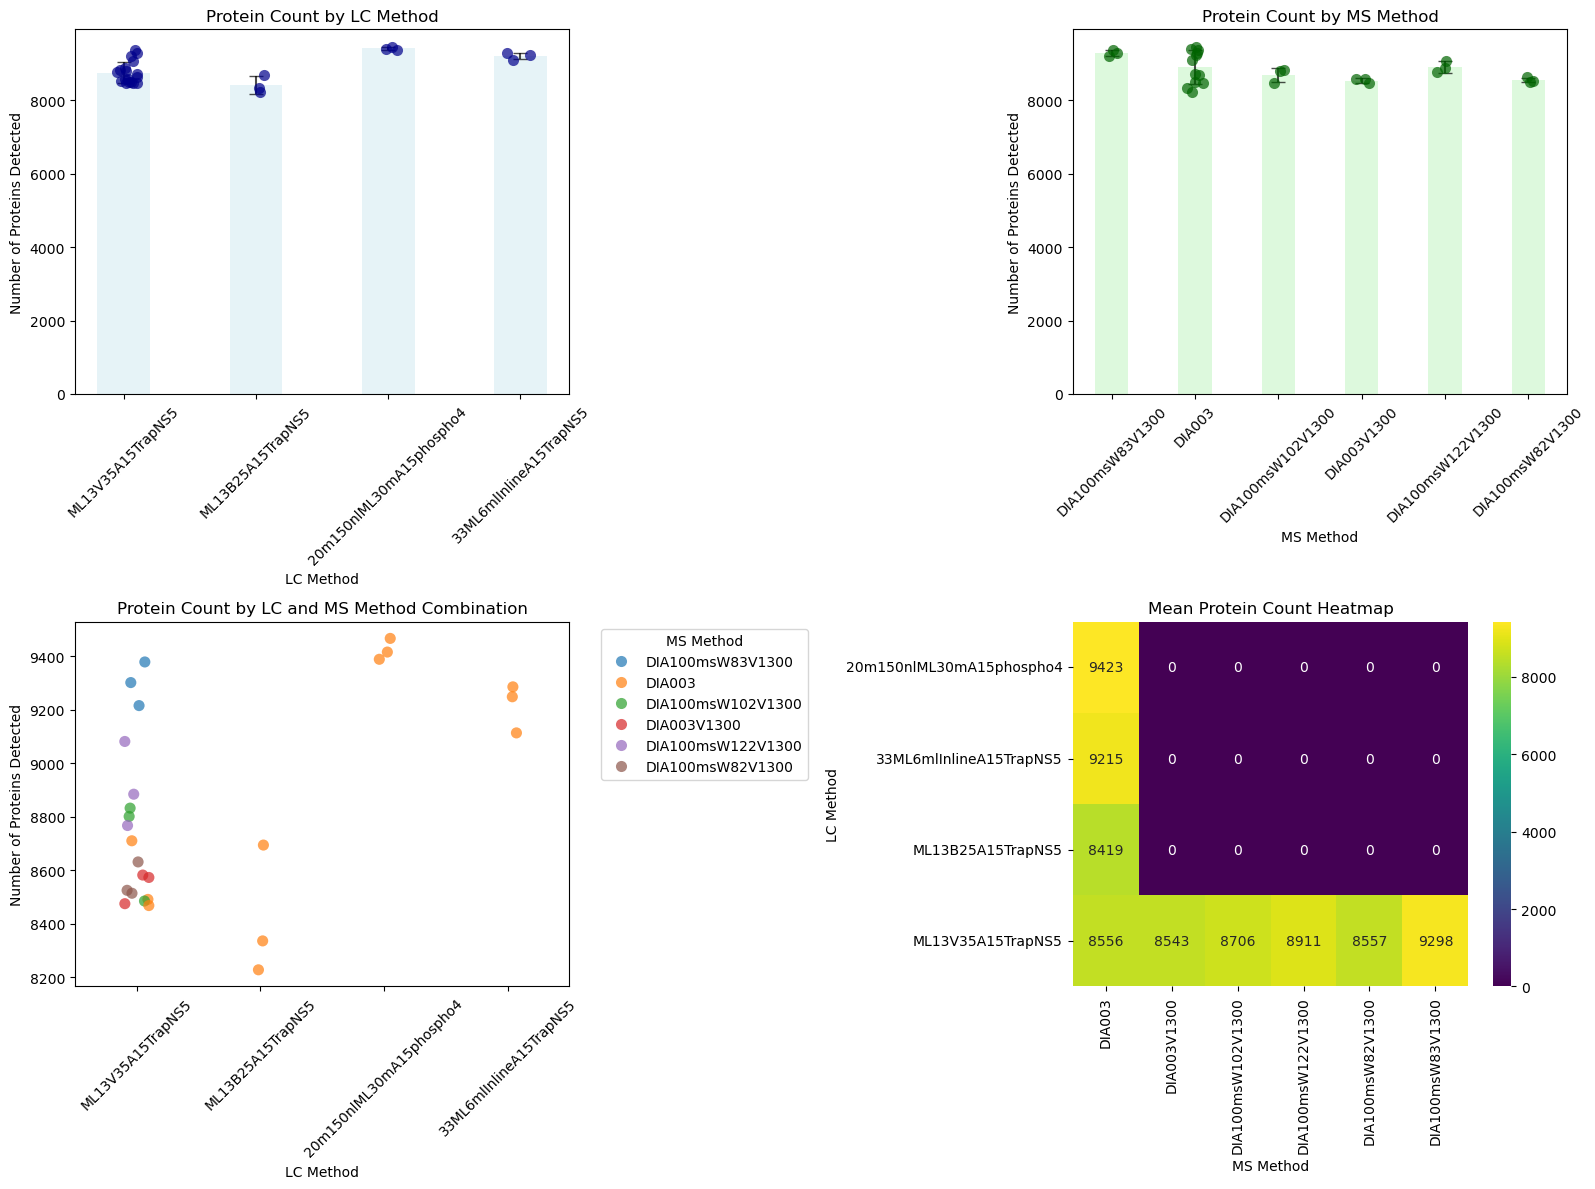


Overall Statistics:
Total samples: 27
Average proteins per sample: 8847.6
Range: 8228 - 9466 proteins

Breakdown by Method Combination:
20m150nlML30mA15phospho4 + DIA003: 9423.0 ± 39.6 proteins (n=3)
33ML6mlInlineA15TrapNS5 + DIA003: 9215.3 ± 90.5 proteins (n=3)
ML13B25A15TrapNS5 + DIA003: 8419.3 ± 243.9 proteins (n=3)
ML13V35A15TrapNS5 + DIA003: 8556.3 ± 133.6 proteins (n=3)
ML13V35A15TrapNS5 + DIA003V1300: 8543.3 ± 59.3 proteins (n=3)
ML13V35A15TrapNS5 + DIA100msW102V1300: 8706.0 ± 192.0 proteins (n=3)
ML13V35A15TrapNS5 + DIA100msW122V1300: 8910.7 ± 158.7 proteins (n=3)
ML13V35A15TrapNS5 + DIA100msW82V1300: 8556.7 ± 64.6 proteins (n=3)
ML13V35A15TrapNS5 + DIA100msW83V1300: 9298.0 ± 81.5 proteins (n=3)


In [33]:
# Create comprehensive protein count visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Count plot by LC method only
sns.stripplot(data=prot_counts_dn_df, 
              x='lc_meth', 
              y='protein_count',
              size=8,
              alpha=0.7, 
              ax=ax1,
              color='darkblue')

# Add mean bars for LC method
lc_summary = prot_counts_dn_df.groupby('lc_meth')['protein_count'].agg(['mean', 'std']).reset_index()
bars1 = ax1.bar(lc_summary['lc_meth'], lc_summary['mean'], 
                alpha=0.3, color='lightblue', width=0.4)
ax1.errorbar(lc_summary['lc_meth'], lc_summary['mean'], 
             yerr=lc_summary['std'], fmt='none', 
             color='black', capsize=5, alpha=0.7)

ax1.set_ylabel('Number of Proteins Detected')
ax1.set_xlabel('LC Method')
ax1.set_title('Protein Count by LC Method')
ax1.tick_params(axis='x', rotation=45)

# 2. Count plot by MS method only  
sns.stripplot(data=prot_counts_dn_df,
              x='ms_meth',
              y='protein_count', 
              size=8,
              alpha=0.7,
              ax=ax2,
              color='darkgreen')

# Add mean bars for MS method
ms_summary = prot_counts_dn_df.groupby('ms_meth')['protein_count'].agg(['mean', 'std']).reset_index() 
bars2 = ax2.bar(ms_summary['ms_meth'], ms_summary['mean'],
                alpha=0.3, color='lightgreen', width=0.4)
ax2.errorbar(ms_summary['ms_meth'], ms_summary['mean'],
             yerr=ms_summary['std'], fmt='none',
             color='black', capsize=5, alpha=0.7)

ax2.set_ylabel('Number of Proteins Detected')
ax2.set_xlabel('MS Method')
ax2.set_title('Protein Count by MS Method')
ax2.tick_params(axis='x', rotation=45)

# 3. Combined method visualization - grouped bar plot
sns.stripplot(data=prot_counts_dn_df,
              x='lc_meth', 
              y='protein_count',
              hue='ms_meth',
              size=8,
              alpha=0.7,
              ax=ax3)

ax3.set_ylabel('Number of Proteins Detected')
ax3.set_xlabel('LC Method')
ax3.set_title('Protein Count by LC and MS Method Combination')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='MS Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Heatmap showing mean protein counts by method combination
pivot_data = prot_counts_dn_df.groupby(['lc_meth', 'ms_meth'])['protein_count'].mean().unstack(fill_value=0)
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='viridis', ax=ax4)
ax4.set_title('Mean Protein Count Heatmap')
ax4.set_xlabel('MS Method')
ax4.set_ylabel('LC Method')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nOverall Statistics:")
print(f"Total samples: {len(prot_counts_dn_df)}")
print(f"Average proteins per sample: {prot_counts_dn_df['protein_count'].mean():.1f}")
print(f"Range: {prot_counts_dn_df['protein_count'].min()} - {prot_counts_dn_df['protein_count'].max()} proteins")

print(f"\nBreakdown by Method Combination:")
for _, row in prot_summary_dn.iterrows():
    print(f"{row['method_combo']}: {row['mean']:.1f} ± {row['std']:.1f} proteins (n={row['count']})")

In [ ]:
# Alternative: Simple focused count plot showing method combinations
fig, ax = plt.subplots(figsize=(12, 8))

# Create a stripplot with different colors for each MS method
unique_ms_methods = prot_counts_dn_df['ms_meth'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_ms_methods)))

for i, ms_method in enumerate(unique_ms_methods):
    subset = prot_counts_dn_df[prot_counts_dn_df['ms_meth'] == ms_method]
    
    # Offset x positions slightly for different MS methods
    x_offset = (i - len(unique_ms_methods)/2 + 0.5) * 0.1
    
    # Create stripplot for this MS method
    for j, lc_method in enumerate(subset['lc_meth'].unique()):
        lc_subset = subset[subset['lc_meth'] == lc_method]
        x_pos = [j + x_offset] * len(lc_subset)
        
        ax.scatter(x_pos, lc_subset['protein_count'], 
                  color=colors[i], alpha=0.7, s=60,
                  label=ms_method if j == 0 else "")

# Add mean lines for each combination
for i, (name, group) in enumerate(prot_counts_dn_df.groupby(['lc_meth', 'ms_meth'])):
    lc_method, ms_method = name
    mean_count = group['protein_count'].mean()
    std_count = group['protein_count'].std()
    
    # Find x position for this LC method
    lc_methods = sorted(prot_counts_dn_df['lc_meth'].unique())
    lc_idx = lc_methods.index(lc_method)
    ms_idx = list(unique_ms_methods).index(ms_method)
    x_offset = (ms_idx - len(unique_ms_methods)/2 + 0.5) * 0.1
    
    # Draw mean line
    ax.hlines(mean_count, lc_idx + x_offset - 0.05, lc_idx + x_offset + 0.05, 
             colors='red', linewidth=3, alpha=0.8)

# Customize plot
ax.set_xticks(range(len(lc_methods)))
ax.set_xticklabels(lc_methods, rotation=45, ha='right')
ax.set_ylabel('Number of Proteins Detected')
ax.set_xlabel('LC Method')
ax.set_title('Protein Detection Count by LC and MS Method Combination')
ax.legend(title='MS Method', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Create protein count analysis for prot1
# Get protein quantity data and count non-zero proteins per sample
prot_data = pd.DataFrame(prot1.layers['pg_quantity_ms1'], 
                        columns=prot1.var_names,
                        index=prot1.obs_names)

# Count proteins detected per sample (non-zero values)
protein_counts = (prot_data > 0).sum(axis=0)

# Create a dataframe for plotting
prot_counts_df = pd.DataFrame({
    'sample': protein_counts.index,
    'protein_count': protein_counts.values
})

# Extract LC method information directly
prot_counts_df['lc_meth'] = prot1.var['lc meth'].values

# Group by LC method for plotting
prot_summary = prot_counts_df.groupby('lc_meth')['protein_count'].agg(['mean', 'std', 'count']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Individual sample points
sns.stripplot(data=prot_counts_df, 
              x='lc_meth', 
              y='protein_count',
              size=8,
              alpha=0.7, 
              ax=ax,
              color='darkblue')

# Mean bars
bars = ax.bar(prot_summary['lc_meth'], prot_summary['mean'], 
              alpha=0.3, color='lightblue', width=0.4)

# Line connecting means if multiple methods
if len(prot_summary) > 1:
    ax.plot(prot_summary['lc_meth'], prot_summary['mean'], 
            color='red', marker='o', linewidth=2, markersize=8, 
            label='Mean', alpha=0.8)

# Error bars
ax.errorbar(prot_summary['lc_meth'], prot_summary['mean'], 
            yerr=prot_summary['std'], fmt='none', 
            color='black', capsize=5, alpha=0.7)

ax.set_ylabel('Number of Proteins Detected')
ax.set_xlabel('LC Method')
ax.set_title('Protein Detection Count per Sample by LC Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total samples: {len(prot_counts_df)}")
print(f"Average proteins per sample: {prot_counts_df['protein_count'].mean():.1f}")
print(f"Range: {prot_counts_df['protein_count'].min()} - {prot_counts_df['protein_count'].max()} proteins")
print("\\nSummary by LC Method:")
for method in prot_summary['lc_meth']:
    method_data = prot_summary[prot_summary['lc_meth'] == method].iloc[0]
    print(f"{method}: {method_data['mean']:.1f} ± {method_data['std']:.1f} proteins (n={method_data['count']})")



## Adjusted LC Meth

In [ ]:
spnt_collection['peptide'].var[spnt_collection['peptide'].var['lc meth'].isin(['ML13V35A15TrapNS5', 'ML13B25A15TrapNS5'])]['sample_name'].iloc[20]

'HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF_B-H2_1_15700'

In [ ]:
lccollection.bulk_adjust_gradients(spnt_collection)

In [ ]:
short_var = spnt_collection['peptide'].var[spnt_collection['peptide'].var['sample_name'].isin(['HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732',
                                                                                                     'HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF_B-H2_1_15700'])]

In [ ]:
lccollection.adjusted_methods['ML13V35A15TrapNS5']['HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732'].gradient

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Neo.PumpModule.Pump.StartColumnWash,length [min],volume (nL),total volume (nL),Total + Dead Volume (nL),Actual Time to Elute Nominal %B (min),Actual %B
0,0.00,0.75,2.0,5,NaN,0.00,0.0,0.0,1625.481048,2.236540,2.000000
1,1.50,0.75,28.0,5,NaN,1.50,1125.0,1125.0,2750.481048,9.736540,2.000000
2,2.00,0.75,40.0,5,NaN,0.50,375.0,1500.0,3125.481048,10.335481,2.000000
3,2.15,0.75,40.0,5,NaN,0.15,112.5,1612.5,3237.981048,10.447981,2.000000
4,2.25,0.15,40.0,5,NaN,0.10,15.0,1627.5,3252.981048,10.462981,2.046660
5,6.25,0.15,40.0,5,1.0,4.00,600.0,2227.5,3852.981048,11.062981,15.913327
6,7.25,0.15,95.0,5,NaN,1.00,150.0,2377.5,4002.981048,11.212981,19.379994
7,10.00,0.15,95.0,5,NaN,2.75,412.5,2790.0,4415.481048,11.625481,33.278513
8,11.00,1.00,50.0,5,NaN,1.00,1000.0,3790.0,5415.481048,12.625481,40.000000
9,13.00,1.00,50.0,5,NaN,2.00,2000.0,5790.0,7415.481048,13.000000,50.000000


In [ ]:
spnt_collection['peptide'][:, spnt_collection['peptide'].var['sample_name'] == 'HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732']

View of AnnData object with n_obs × n_vars = 134513 × 1
    obs: 'stripped_peptide', 'ptms', 'ptm_locations', 'precursor_mz', 'precursor_charge', 'obs_unique'
    var: 'processing_run_uuid', 'sample_name', 'lc meth', 'ms meth'
    layers: 'ptm_confidence_index', 'ptm_confidence_values', 'ptm_confidence_locations', 'precursor_quantity', 'precursor_q_value', 'rt', 'irt', 'measured_ook0', 'mass_accuracy', 'peptide_n_missed_cleavages', 'precursor_quantity_ms1', 'precursor_quantity_ms2', 'precursor_mz_calibrated', 'rt_start', 'rt_end', 'predicted_irt', 'predicted_rt', 'precursor_fwhm', 'is_proteotypic', 'is_imputed', 'shape_quality', 'pep_score', 'c_score', 'c_score_normalised'

In [16]:
prot1 = spnt_collection['protein'][:, spnt_collection['protein'].var['lc meth'].isin(['ML13V35A15TrapNS5', 'ML13B25A15TrapNS5']) & (spnt_collection['protein'].var['ms meth'] =='DIA003')]

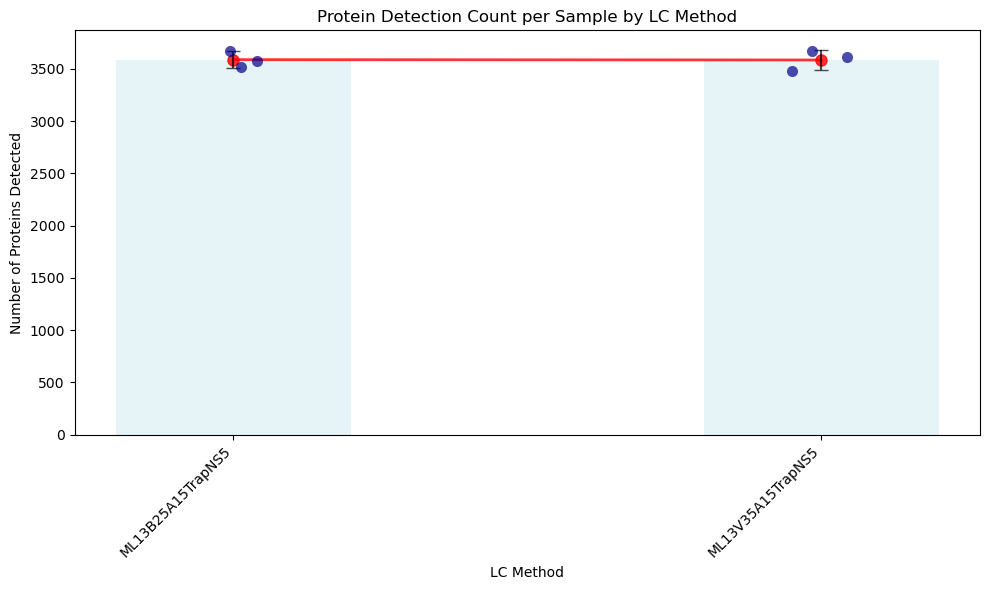

Total samples: 6
Average proteins per sample: 3586.3
Range: 3475 - 3673 proteins
\nSummary by LC Method:
ML13B25A15TrapNS5: 3588.0 ± 79.3 proteins (n=3)
ML13V35A15TrapNS5: 3584.7 ± 99.5 proteins (n=3)


In [24]:
# Create protein count analysis for prot1
# Get protein quantity data and count non-zero proteins per sample
prot_data = pd.DataFrame(prot1.layers['pg_quantity_ms1'], 
                        columns=prot1.var_names,
                        index=prot1.obs_names)

# Count proteins detected per sample (non-zero values)
protein_counts = (prot_data > 0).sum(axis=0)

# Create a dataframe for plotting
prot_counts_df = pd.DataFrame({
    'sample': protein_counts.index,
    'protein_count': protein_counts.values
})

# Extract LC method information directly
prot_counts_df['lc_meth'] = prot1.var['lc meth'].values

# Group by LC method for plotting
prot_summary = prot_counts_df.groupby('lc_meth')['protein_count'].agg(['mean', 'std', 'count']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Individual sample points
sns.stripplot(data=prot_counts_df, 
              x='lc_meth', 
              y='protein_count',
              size=8,
              alpha=0.7, 
              ax=ax,
              color='darkblue')

# Mean bars
bars = ax.bar(prot_summary['lc_meth'], prot_summary['mean'], 
              alpha=0.3, color='lightblue', width=0.4)

# Line connecting means if multiple methods
if len(prot_summary) > 1:
    ax.plot(prot_summary['lc_meth'], prot_summary['mean'], 
            color='red', marker='o', linewidth=2, markersize=8, 
            label='Mean', alpha=0.8)

# Error bars
ax.errorbar(prot_summary['lc_meth'], prot_summary['mean'], 
            yerr=prot_summary['std'], fmt='none', 
            color='black', capsize=5, alpha=0.7)

ax.set_ylabel('Number of Proteins Detected')
ax.set_xlabel('LC Method')
ax.set_title('Protein Detection Count per Sample by LC Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total samples: {len(prot_counts_df)}")
print(f"Average proteins per sample: {prot_counts_df['protein_count'].mean():.1f}")
print(f"Range: {prot_counts_df['protein_count'].min()} - {prot_counts_df['protein_count'].max()} proteins")
print("\\nSummary by LC Method:")
for method in prot_summary['lc_meth']:
    method_data = prot_summary[prot_summary['lc_meth'] == method].iloc[0]
    print(f"{method}: {method_data['mean']:.1f} ± {method_data['std']:.1f} proteins (n={method_data['count']})")



Text(0.5, 1.0, 'Distribution of Peptide Retention Times with Adjusted Gradients')

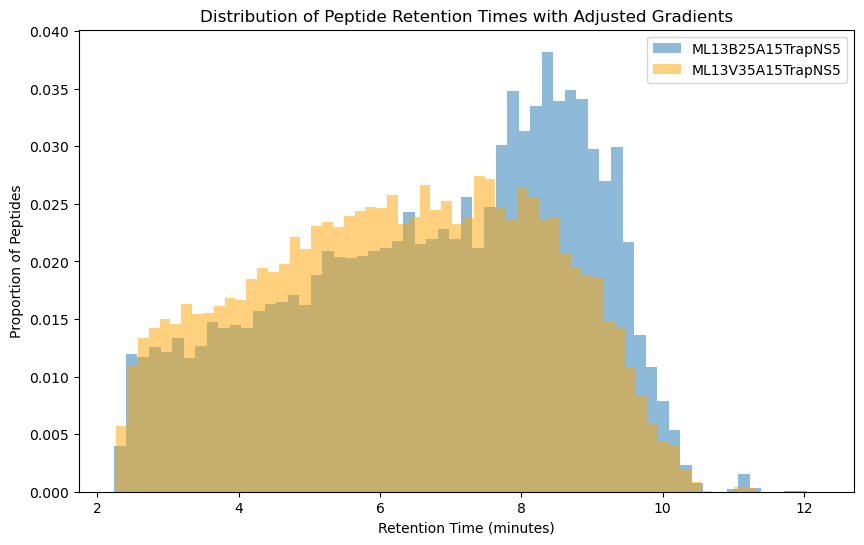

In [ ]:
prot1
sns.histplot(x = spnt_collection['peptide'][:, spnt_collection['peptide'].var['sample_name'] =='HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF_B-H2_1_15700'].layers['rt'].flatten(), 
             ax=ax,
             alpha=0.5,
             edgecolor=None,
             stat='proportion')
sns.histplot(x = spnt_collection['peptide'][:, spnt_collection['peptide'].var['sample_name'] == 'HeLaI5ng_Ddil_F1_R1_T1_DIA100msW122V1300-ML13V35A15TrapNS5_012959_VNTT006_timsTOF_B-H2_1_15732'].layers['rt'].flatten(), 
             ax=ax,
             alpha=0.5,
             edgecolor=None,
             color='orange',
             stat='proportion')
plt.legend(['ML13B25A15TrapNS5', 'ML13V35A15TrapNS5'])
plt.ylabel('Proportion of Peptides')
plt.xlabel('Retention Time (minutes)')
plt.title("Distribution of Peptide Retention Times with Adjusted Gradients")

In [ ]:
temp = spnt_collection['peptide'][:, spnt_collection['peptide'].var['lc meth'].isin(['ML13V35A15TrapNS5', 'ML13B25A15TrapNS5']) & (spnt_collection['peptide'].var['ms meth'] == 'DIA003')]

In [472]:
temp2 = spnt_collection['peptide'][:, (spnt_collection['peptide'].var['lc meth'] == 'ML13V35A15TrapNS5') & (spnt_collection['peptide'].var['ms meth'] != 'DIA003')]

In [476]:
groups2 = temp2.var.groupby('ms meth').agg(list)['processing_run_uuid']

In [483]:
groups2

ms meth
DIA003V1300          [643e2212-07d9-45bc-bcb0-68823987bd7e, 6f24c7d...
DIA100msW102V1300    [f29d455a-2f93-4504-8de4-938c86d568e8, 04f8ec8...
DIA100msW122V1300    [9135415d-a70c-4edd-84f2-2fd2d98505fc, dbe24c5...
DIA100msW82V1300     [b5c35493-3603-4409-8fe5-714ff0708b46, 44f2d1c...
DIA100msW83V1300     [e5870a46-49bd-48b1-9e18-bb7e911d6549, c471696...
Name: processing_run_uuid, dtype: object

In [481]:
# Append all lists in groups2 together
all_groups2_samples = []
for sample_list in groups2:
    all_groups2_samples.extend(sample_list)


In [482]:
test3 = pd.DataFrame(temp2[:, temp2.var['processing_run_uuid'].isin(all_groups2_samples)].layers['precursor_quantity'], columns=all_groups2_samples)

In [484]:
test3 = test3.melt()
test3['meth'] = test3['variable'].apply(lambda x: 
    next((method for method, samples in groups2.items() if x in samples), 'Unknown')
)

In [486]:
test4 = test3.groupby('variable').agg({'value': lambda x: (x > 0).sum(), 'meth': 'first'})

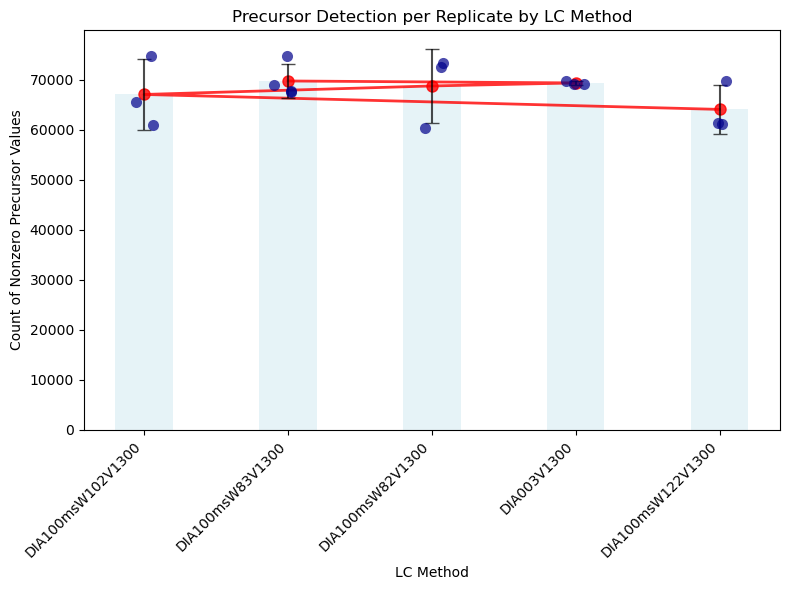

In [489]:
# Create figure with both bar plot and individual points
fig, ax = plt.subplots(figsize=(8, 6))

# Plot individual replicate points (count of nonzero values per replicate)
sns.stripplot(data=test4, 
              x='meth', 
              y='value',
              size=8,
              alpha=0.7, 
              ax=ax,
              color='darkblue')

# Add a bar plot showing mean values
test4_summary = test4.groupby('meth')['value'].agg(['mean', 'std']).reset_index()

# Sort by mean values (descending order - highest to lowest)
test4_summary = test4_summary.sort_values('mean', ascending=False)

bars = ax.bar(test4_summary['meth'], test4_summary['mean'], 
              alpha=0.3, color='lightblue', width=0.4)

# Add line plot connecting the means
ax.plot(test4_summary['meth'], test4_summary['mean'], 
        color='red', marker='o', linewidth=2, markersize=8, 
        label='Mean', alpha=0.8)

# Add error bars
ax.errorbar(test4_summary['meth'], test4_summary['mean'], 
            yerr=test4_summary['std'], fmt='none', 
            color='black', capsize=5, alpha=0.7)

ax.set_ylabel('Count of Nonzero Precursor Values')
ax.set_xlabel('LC Method')
ax.set_title('Precursor Detection per Replicate by LC Method')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
groups = temp.var.groupby('lc meth').agg(list)['processing_run_uuid']

In [444]:
groups.iloc[0] + groups.iloc[1]

['5cc4b4d9-e539-48c3-8898-3bea0320cf11',
 '2c633374-8761-417a-b610-2b15dc1baa90',
 'f3ad1d23-0bde-491e-89ae-9a5d2a9136cf',
 '8d65f050-6f6e-427d-8682-4813db9eaf96',
 '6c885f10-66b1-4b33-941c-6f50dc9deeec',
 'ab770659-b31e-49b1-9d11-4dda99ff4379']

lc meth
ML13B25A15TrapNS5    [5cc4b4d9-e539-48c3-8898-3bea0320cf11, 2c63337...
ML13V35A15TrapNS5    [8d65f050-6f6e-427d-8682-4813db9eaf96, 6c885f1...
Name: processing_run_uuid, dtype: object

In [449]:
test = pd.DataFrame(temp[:, temp.var['processing_run_uuid'].isin(groups.iloc[0] + groups.iloc[1])].layers['precursor_quantity'], columns=groups.iloc[0] + groups.iloc[1])

In [452]:
test = test.melt()
test['meth'] = test['variable'].apply(lambda x: 'ML13V35A15TrapNS5' if x in groups.iloc[0] else 'ML13B25A15TrapNS5')

In [459]:
test2 = test.groupby('variable').agg({'value': lambda x: (x > 0).sum(), 'meth': 'first'})

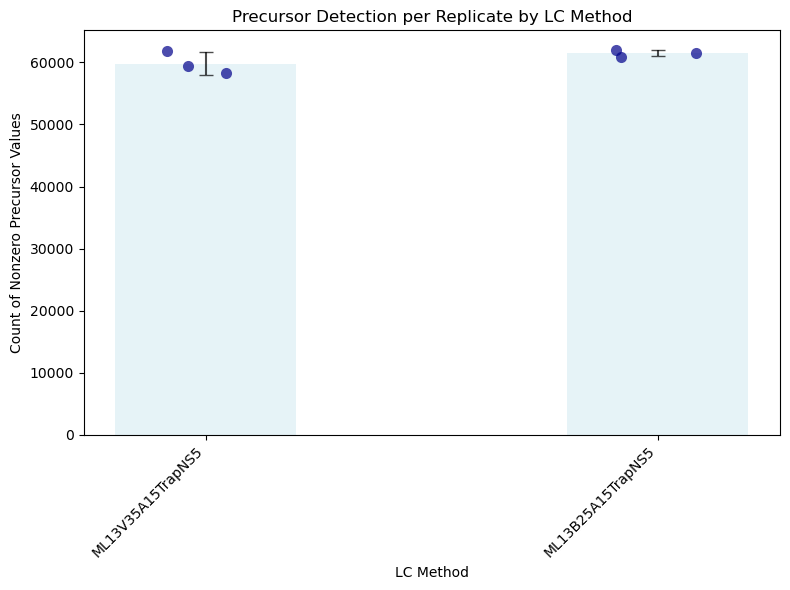

In [463]:
# Create figure with both bar plot and individual points
fig, ax = plt.subplots(figsize=(8, 6))

# Plot individual replicate points (count of nonzero values per replicate)
sns.stripplot(data=test2, 
              x='meth', 
              y='value',
              size=8,
              alpha=0.7, 
              ax=ax,
              color='darkblue')

# Add a bar plot showing mean values
test2_summary = test2.groupby('meth')['value'].agg(['mean', 'std']).reset_index()
bars = ax.bar(test2_summary['meth'], test2_summary['mean'], 
              alpha=0.3, color='lightblue', width=0.4)

# Add error bars
ax.errorbar(test2_summary['meth'], test2_summary['mean'], 
            yerr=test2_summary['std'], fmt='none', 
            color='black', capsize=5, alpha=0.7)

ax.set_ylabel('Count of Nonzero Precursor Values')
ax.set_xlabel('LC Method')
ax.set_title('Precursor Detection per Replicate by LC Method')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ML13B25A15TrapNS5 (3 replicates):
  Total precursors detected: 78133
  Detected in 1 replicate only: 18058
  Detected in 2 replicates only: 15299
  Detected in all 3 replicates: 44776

ML13V35A15TrapNS5 (3 replicates):
  Total precursors detected: 77286
  Detected in 1 replicate only: 17502
  Detected in 2 replicates only: 15850
  Detected in all 3 replicates: 43934



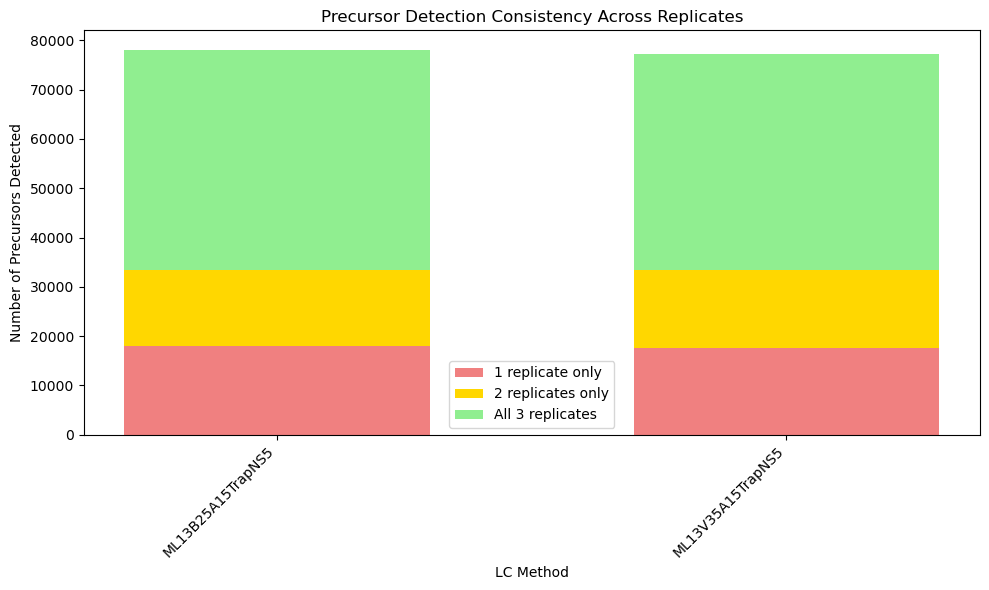

In [384]:
# Dictionary to store results for each method
detection_results = {}

for lc_method, sample_list in groups.items():
    # Get the data for this LC method
    method_data = pd.DataFrame(temp[:, temp.var['processing_run_uuid'].isin(sample_list)].layers['precursor_quantity'])
    
    # Count detections per precursor (row) across replicates (columns)
    detections_per_precursor = (method_data > 0).sum(axis=1)
    
    # Count precursors by detection frequency
    total_replicates = len(sample_list)
    
    # At least 1 replicate
    detected_in_1_plus = (detections_per_precursor >= 1).sum()
    
    # Detected in 2+ replicates (if we have 3 replicates)
    detected_in_2_plus = (detections_per_precursor >= 2).sum() if total_replicates >= 2 else 0
    
    # Detected in 3+ replicates (if we have 3 replicates)  
    detected_in_3_plus = (detections_per_precursor >= 3).sum() if total_replicates >= 3 else 0
    
    # Calculate exclusive categories for stacking
    only_1_replicate = detected_in_1_plus - detected_in_2_plus
    only_2_replicates = detected_in_2_plus - detected_in_3_plus
    all_3_replicates = detected_in_3_plus
    
    detection_results[lc_method] = {
        'total_replicates': total_replicates,
        'detected_1_only': only_1_replicate,
        'detected_2_only': only_2_replicates, 
        'detected_all_3': all_3_replicates,
        'total_detected': detected_in_1_plus
    }
    
    print(f"{lc_method} ({total_replicates} replicates):")
    print(f"  Total precursors detected: {detected_in_1_plus}")
    print(f"  Detected in 1 replicate only: {only_1_replicate}")
    print(f"  Detected in 2 replicates only: {only_2_replicates}")
    print(f"  Detected in all 3 replicates: {all_3_replicates}")
    print()

# Create the stacked bar plot
methods = list(detection_results.keys())
detected_1_only = [detection_results[m]['detected_1_only'] for m in methods]
detected_2_only = [detection_results[m]['detected_2_only'] for m in methods]
detected_all_3 = [detection_results[m]['detected_all_3'] for m in methods]

fig, ax = plt.subplots(figsize=(10, 6))

# Create stacked bars
bar_width = 0.6
bars1 = ax.bar(methods, detected_1_only, bar_width, label='1 replicate only', color='lightcoral')
bars2 = ax.bar(methods, detected_2_only, bar_width, bottom=detected_1_only, label='2 replicates only', color='gold')
bars3 = ax.bar(methods, detected_all_3, bar_width, 
               bottom=[i+j for i,j in zip(detected_1_only, detected_2_only)], 
               label='All 3 replicates', color='lightgreen')

# # Add value labels on bars
for i, method in enumerate(methods):
    total = detection_results[method]['total_detected']
#     ax.text(i, total + 50, str(total), ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Number of Precursors Detected')
ax.set_xlabel('LC Method')
ax.set_title('Precursor Detection Consistency Across Replicates')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [373]:
num_precursors

0         0
1         1
2         0
3         2
4         2
         ..
134508    3
134509    3
134510    3
134511    0
134512    3
Length: 134513, dtype: int64

In [ ]:
test = lccollection.methods['ML13V35A15TrapNS5'].adjusted_elution(in_place = False,
                                                          dead_volume = 11.5 * 150)

<Axes: xlabel='Actual Time to Elute Nominal %B (min)', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

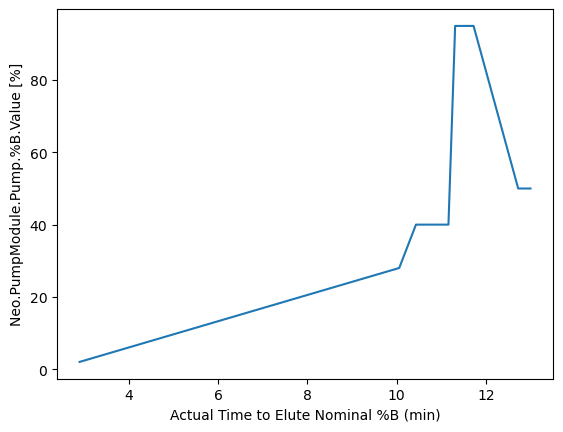

In [ ]:
sns.lineplot(data = test.gradient,
             x = 'Actual Time to Elute Nominal %B (min)',
             y = 'Neo.PumpModule.Pump.%B.Value [%]')

Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]', 'volume (nL)',
       'total volume (nL)', 'Total + Dead Volume (nL)',
       'Actual Time to Elute Nominal %B (min)', 'Actual %B'],
      dtype='object')
Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]', 'volume (nL)',
       'total volume (nL)', 'Total + Dead Volume (nL)',
       'Actual Time to Elute Nominal %B (min)', 'Actual %B'],
      dtype='object')


<Axes: ylabel='Count'>

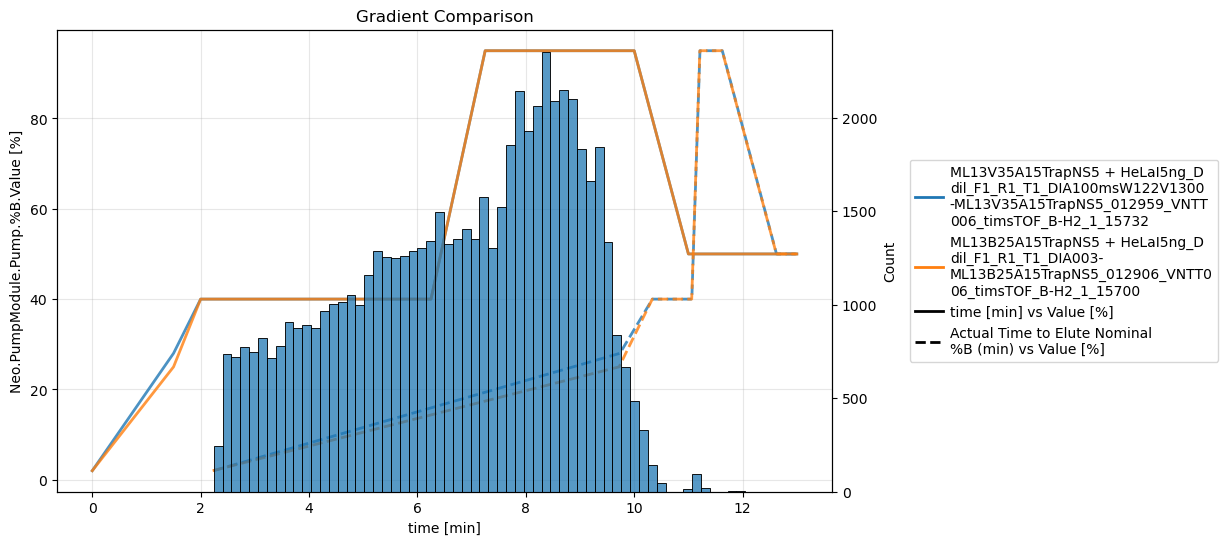

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

lccollection.plot_gradients(sample_var = short_var,
                             x_cols=['time [min]', 'Actual Time to Elute Nominal %B (min)'], 
                             y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                             twin_axes=True, 
                             ax = ax)
ax2 = ax.twinx()
sns.histplot(spnt_collection['peptide'][:, spnt_collection['peptide'].var['sample_name'] == 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF_B-H2_1_15700'].layers['rt'].flatten(), ax=ax2)

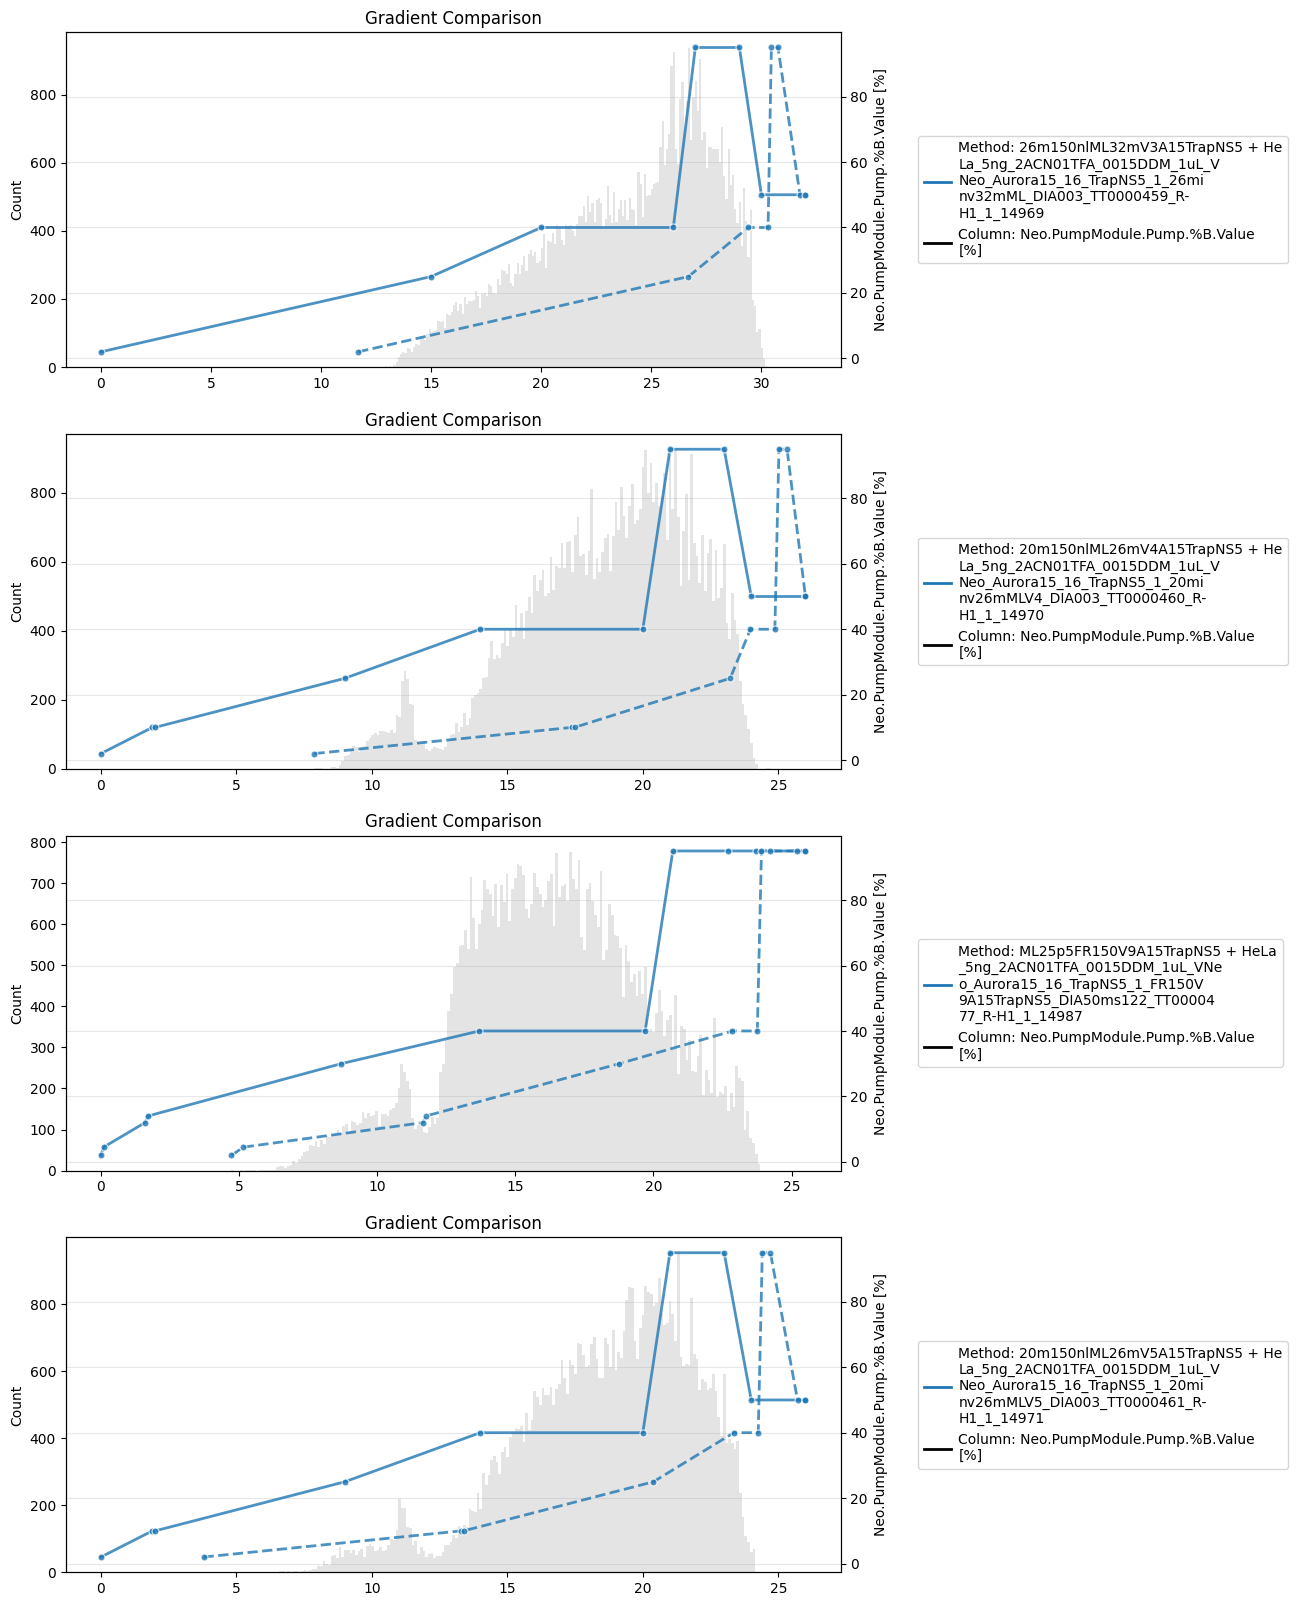

In [ ]:
fig, ax = plt.subplots(figsize=(10, 20), nrows=4)

for i, name in enumerate(test.var_names):
    temp_ax = ax[i].twinx()
    sns.histplot(x = test[:, name].layers['RT'].flatten(), ax=ax[i], edgecolor=None, color='lightgrey', alpha=0.6, binwidth=0.1)
    lccollection.plot_gradients(sample_var = sample_subset.loc[[name]],
                                x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                                y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'],
                                ax=temp_ax, 
                                markers=True)

In [ ]:
dp = DashPlots()
dp.plot_gradients_dash(lccollection);

Dash app running at http://127.0.0.1:8050


[2026-03-23 21:21:51,121] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/flask/app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/flask/app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[ru

<Axes: title={'center': 'Gradient Comparison'}, xlabel='X Value', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

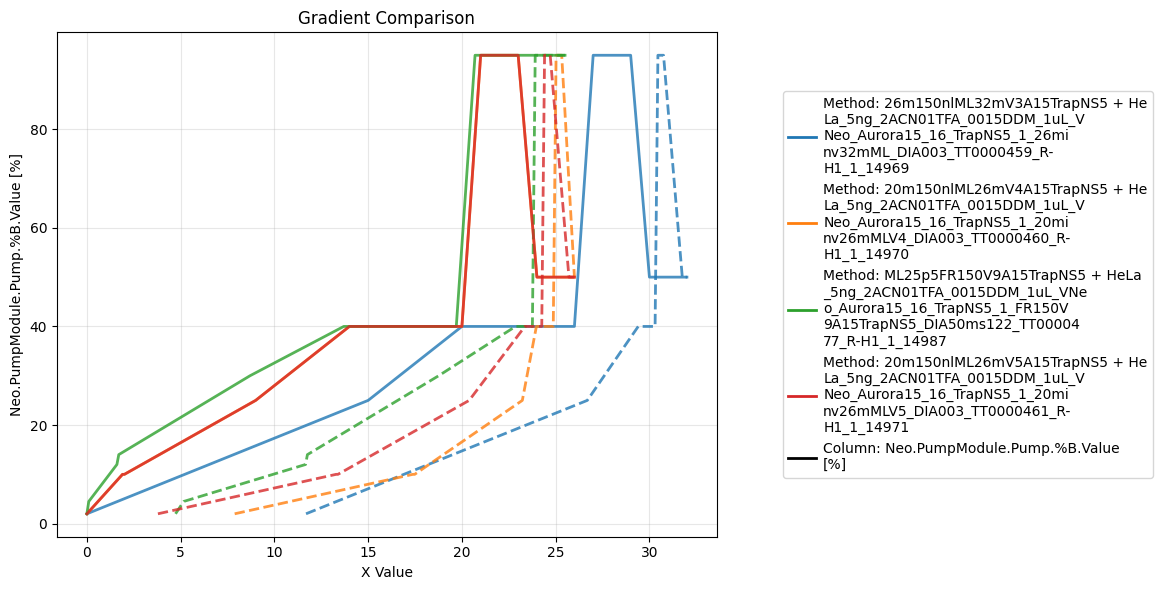

In [ ]:
lccollection.plot_gradients(sample_var = sample_subset,
                            x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                            y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'])

## FWHM Distribution

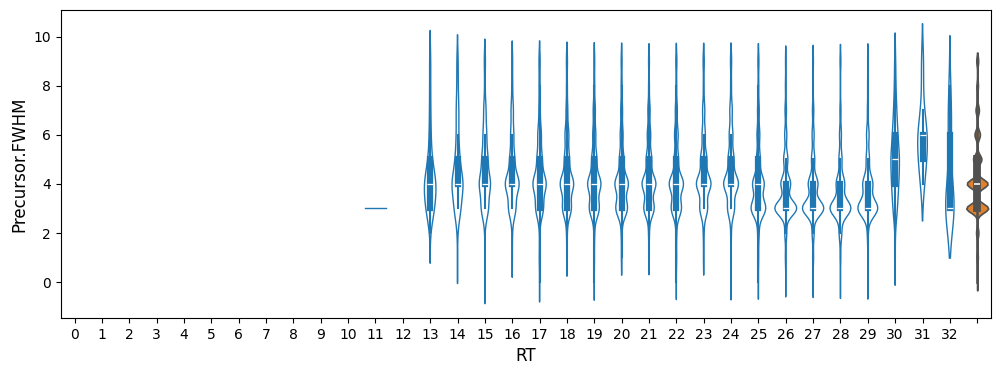

In [ ]:
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1,
           quantity_layer='Precursor.FWHM')


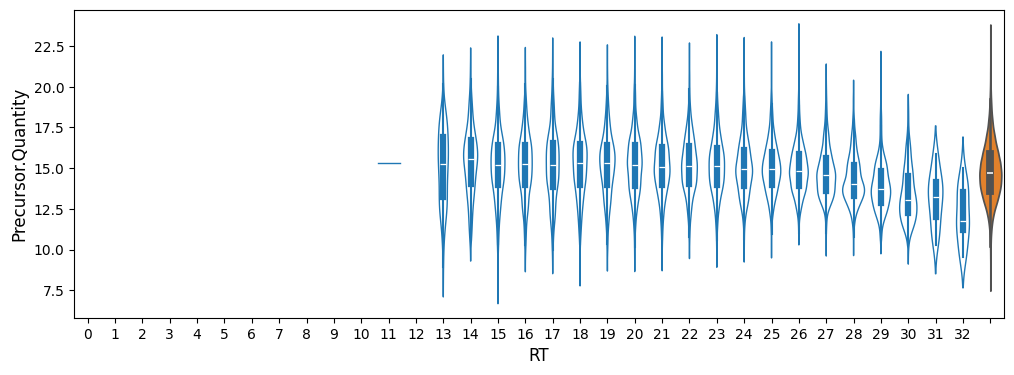

In [ ]:
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1,
           quantity_layer='Precursor.Quantity', 
           log2=True) 


<string>:25: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log2



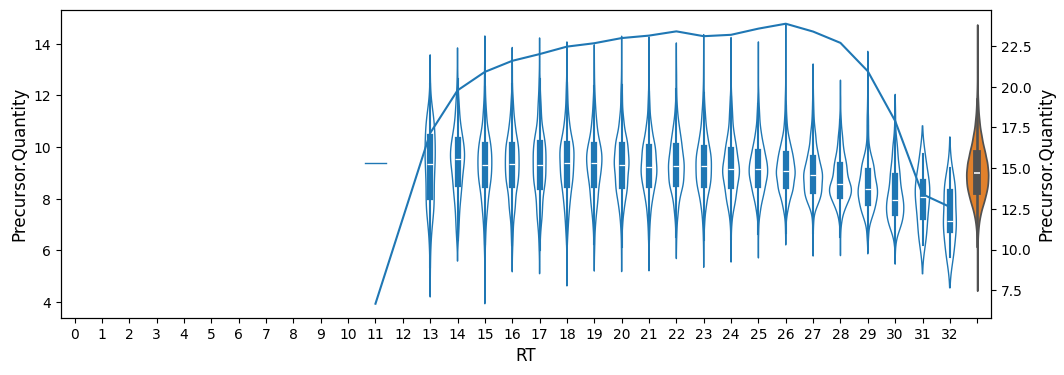

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

twinax = ax.twinx()
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1,
           quantity_layer='Precursor.Quantity', 
           log2=True,
           plot_type='box', 
           ax = ax) 

layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1,
           quantity_layer='Precursor.Quantity', 
           log2=True, 
           ax = twinax) 


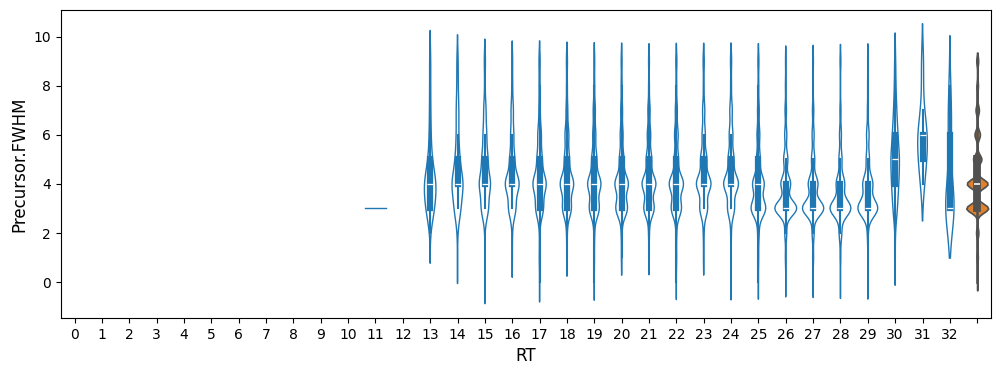

In [ ]:
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1, 
           plot_type='violin', 
           quantity_layer='Precursor.FWHM',) 

<Axes: title={'center': 'Gradient Comparison'}, xlabel='X Value', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

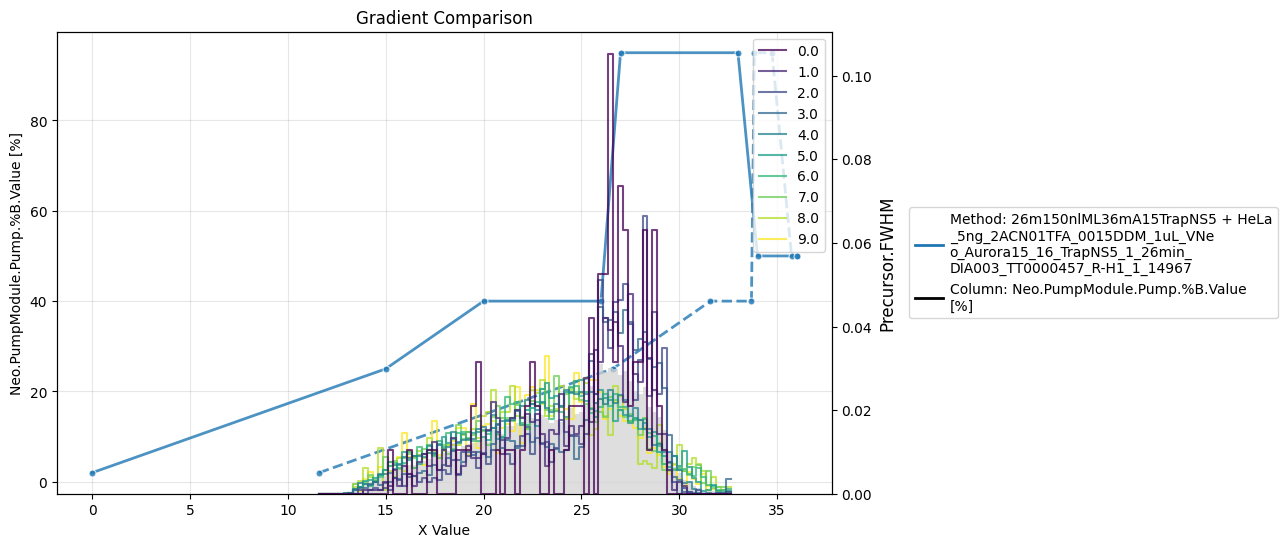

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
twinax = ax.twinx()
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(10, 6), 
           binwidth=0.25,
           plot_type='hist',
           stat='probability',
           overall_dist=True,
           common_norm=False,
           ax=twinax,
           quantity_layer='Precursor.FWHM')


lccollection.plot_gradients(sample_var = bpscollection['precursor'].var.loc[['HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967']],
                            x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                            y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'],
                            ax=ax, 
                            markers=True)

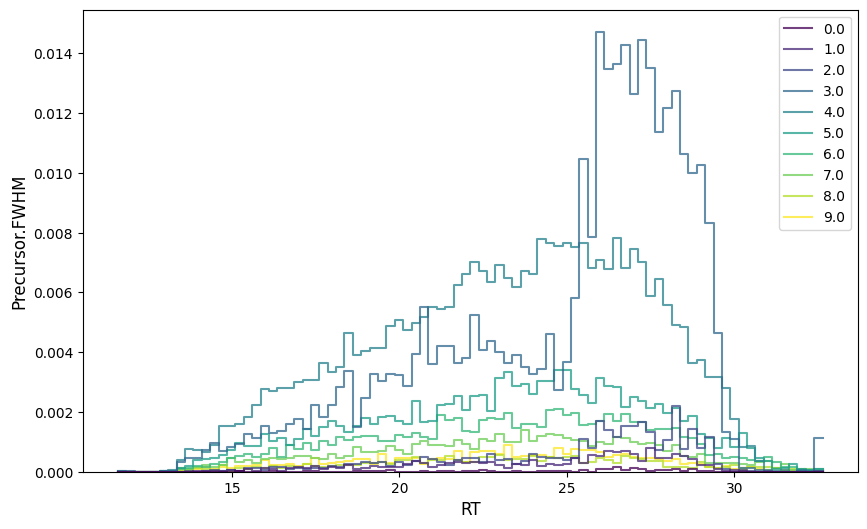

In [ ]:
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(10, 6), 
           binwidth=0.25,
           plot_type='hist',
           stat='probability',
           overall_dist=False,
           quantity_layer='Precursor.FWHM')

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT

## Incorporating pressure curve + trap switch

In [177]:
trap_dead_volume = 150 * 8.8

In [178]:
trap_method = lccollection.methods['ML13B25A15TrapNS5'].copy()
trap_method.adjusted_elution(
    in_place=True, 
    dead_volume=trap_dead_volume,
    direct_only=direct_dead_volume,
    extrapolate_points = [{'time': 0.1, 'b_percent': 2, 'flow_rate': 1},
                          {'time': 1.5, 'b_percent': 2, 'flow_rate': 1}]
)

Trapped volume: 495 nL


/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/src/parsers/vneometh/vneo_method.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  return text


ValueError: Unknown format code 'f' for object of type 'str'

In [179]:
trap_method2 = lccollection.methods['ML13V35A15TrapNS5'].copy()
trap_method2.adjusted_elution(
    in_place=True, 
    dead_volume=trap_dead_volume,
    direct_only=direct_dead_volume,
    extrapolate_points = [{'time': 0.1, 'b_percent': 2, 'flow_rate': 1},
                          {'time': 1.5, 'b_percent': 2, 'flow_rate': 1.5}]
)

Trapped volume: 495 nL


/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/src/parsers/vneometh/vneo_method.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  return text


ValueError: Unknown format code 'f' for object of type 'str'

<Axes: xlabel='Actual Time to Elute Nominal %B (min)', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

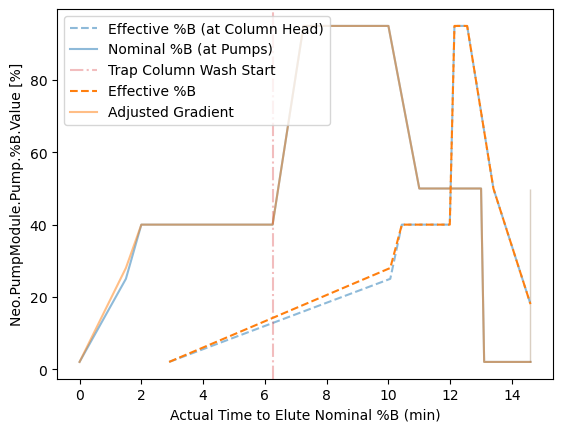

In [154]:
sns.lineplot(data=trap_method.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B (at Column Head)', linestyle='--', color='tab:blue', alpha=0.5)
sns.lineplot(data=trap_method.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', label='Nominal %B (at Pumps)', color='tab:blue', alpha=0.5)
plt.axvline(x=trap_method.gradient['time [min]'][trap_method.gradient['Neo.PumpModule.Pump.StartColumnWash'] == 1].iloc[0], color= 'tab:red', linestyle='-.', label='Trap Column Wash Start', alpha=0.3)


sns.lineplot(data=trap_method2.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B', color='tab:orange', linestyle='--')
sns.lineplot(data=trap_method2.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', label='Adjusted Gradient', color='tab:orange', alpha=0.5)

In [ ]:
"/hpc/projects/mass_spec/eileenwang/VNTT/Raw/VNTT006/BSAI3fmol_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012905_VNTT006_timsTOF.raw"

In [12]:
# Import the NEW .NET Core pressure extraction functionality
from parsers.vneometh.extractor.raw_extractor_dotnet import extract_raw, extract_method

# Extract pressure trace and %B composition from the raw file
raw_file_path = "/hpc/projects/mass_spec/eileenwang/VNTT/Raw/VNTT006/HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF.raw"

pressure_trace = extract_raw(raw_file_path)

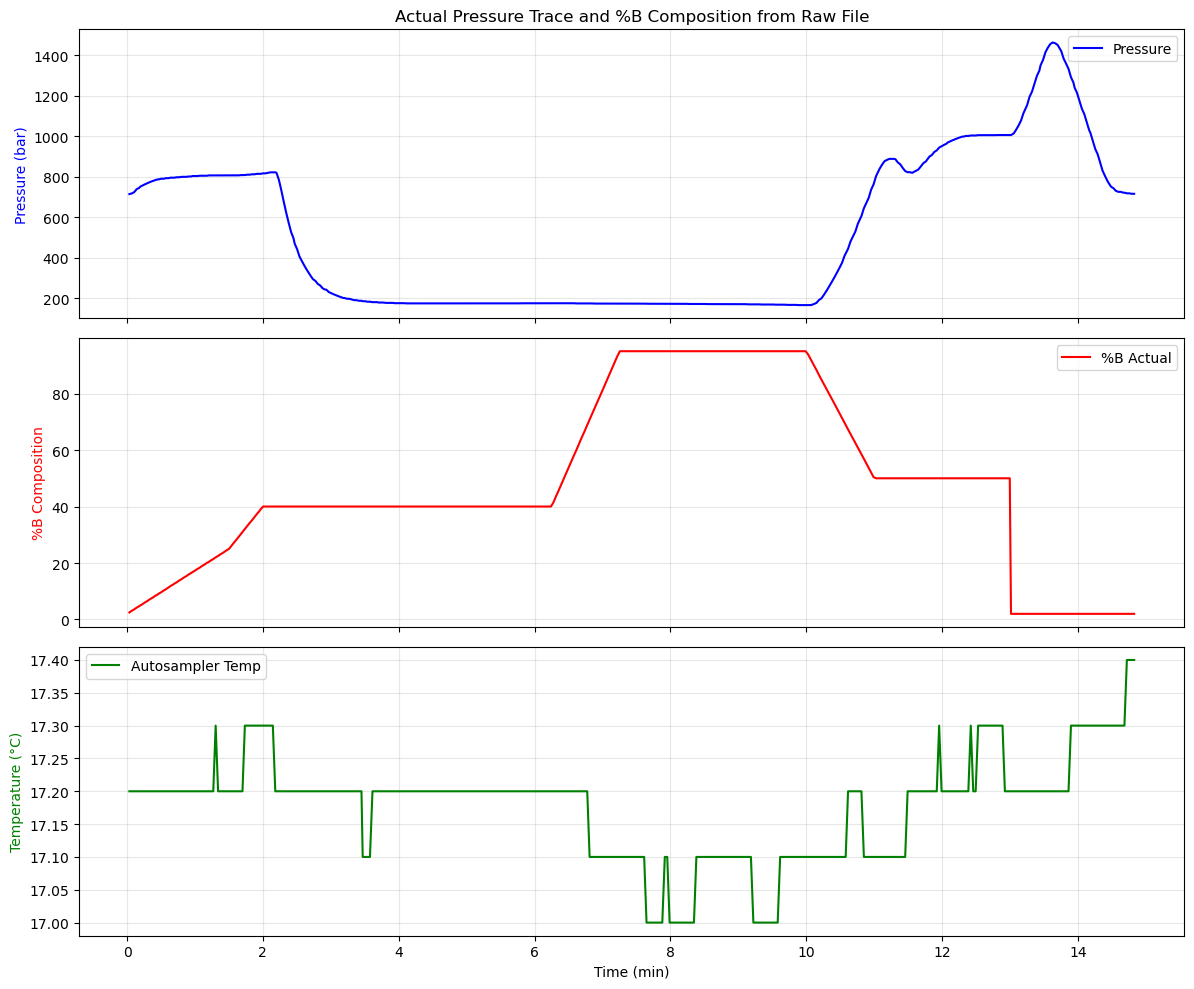

In [13]:
# Plot pressure trace and %B composition
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot pressure trace
ax1.plot(pressure_trace['time_min'], pressure_trace['AnalyticalPumpPressureInBar'], 
         'b-', linewidth=1.5, label='Pressure')
ax1.set_ylabel('Pressure (bar)', color='b')
ax1.set_title('Actual Pressure Trace and %B Composition from Raw File')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot %B composition
ax2.plot(pressure_trace['time_min'], pressure_trace['PercentBComposition'], 
         'r-', linewidth=1.5, label='%B Actual')
ax2.set_ylabel('%B Composition', color='r')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot temperature
ax3.plot(pressure_trace['time_min'], pressure_trace['AmbientAutosamplerTemperatureInC'], 
         'g-', linewidth=1.5, label='Autosampler Temp')
ax3.set_ylabel('Temperature (°C)', color='g')
ax3.set_xlabel('Time (min)')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

In [17]:
# Demonstrate the new pressure trace functionality in adjusted_elution
%reload_ext autoreload

# Example: Use pressure traces to determine flow rates for specific time ranges
raw_file_path = "/hpc/projects/mass_spec/eileenwang/VNTT/Raw/VNTT006/HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF.raw"

# Define time ranges where we want to use actual pressure to determine flow rate
# Each range maps raw file time to method time
pressure_time_ranges = [
    {
        'start_time': 2.2,      # Start time in raw file (minutes) 
        'end_time': 3,        # End time in raw file (minutes)
        'method_time_start': 2.2,  # Corresponding start time in method (minutes)
        'method_time_end': 3     # Corresponding end time in method (minutes)
    },
    {
        'start_time': 11,      # Another time range
        'end_time': 15,       # End time in raw file
        'method_time_start': 11,  # Method time start
        'method_time_end': 15   # Method time end
    }
]

# Test the new functionality
trap_method_with_pressure = lccollection.methods['ML13B25A15TrapNS5'].copy()

# Apply adjusted elution with pressure trace integration
trap_method_with_pressure.adjusted_elution(
    in_place=True,
    dead_volume=trap_dead_volume,
    direct_only=direct_dead_volume,
    # extrapolate_points=[{'time': 0.1, 'b_percent': 2, 'flow_rate': 1},
    #                    {'time': 1.5, 'b_percent': 2, 'flow_rate': 1}],
    raw_file_path=raw_file_path,
    pressure_time_ranges=pressure_time_ranges, 
    pressure_to_flow_ratio=0.15/170
)

Extracting pressure traces from: /hpc/projects/mass_spec/eileenwang/VNTT/Raw/VNTT006/HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF.raw
Time range 2.2-3.0 min (raw): avg pressure = 430 bar
  -> derived flow rate = 0.380 µL/min
  -> applying to method time 2.2-3.0 min
Time range 11.0-15.0 min (raw): avg pressure = 1004 bar
  -> derived flow rate = 0.886 µL/min
  -> applying to method time 11.0-15.0 min
Trapped volume: 495 nL
Trapped %B range: N/A


In [29]:
trap_method_extra = lccollection.methods['ML13B25A15TrapNS5'].copy()

trap_method_extra.adjusted_elution(
    in_place=True,
    dead_volume=trap_dead_volume,
    direct_only=direct_dead_volume,
    # extrapolate_points=[{'time': 0.1, 'b_percent': 2, 'flow_rate': 1},
    #                    {'time': 1.5, 'b_percent': 2, 'flow_rate': 1}],
    raw_file_path=raw_file_path,
    pressure_time_ranges=pressure_time_ranges, 
    pressure_to_flow_ratio=0.15/170,
    use_real_composition=True
)

Extracting pressure and composition traces from: /hpc/projects/mass_spec/eileenwang/VNTT/Raw/VNTT006/HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF.raw
Time range 2.2-3.0 min (raw): avg pressure = 430 bar
  -> derived flow rate = 0.380 µL/min
  -> applying to method time 2.2-3.0 min
Time range 2.2-3.0 min (raw): avg %B composition = 40.0%
  -> applying real %B to method time 2.2-3.0 min
Time range 11.0-15.0 min (raw): avg pressure = 1004 bar
  -> derived flow rate = 0.886 µL/min
  -> applying to method time 11.0-15.0 min
Time range 11.0-15.0 min (raw): avg %B composition = 27.0%
  -> applying real %B to method time 11.0-15.0 min
Trapped volume: 495 nL
Trapped %B range: N/A


<Axes: xlabel='Actual Time to Elute Nominal %B (min)', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

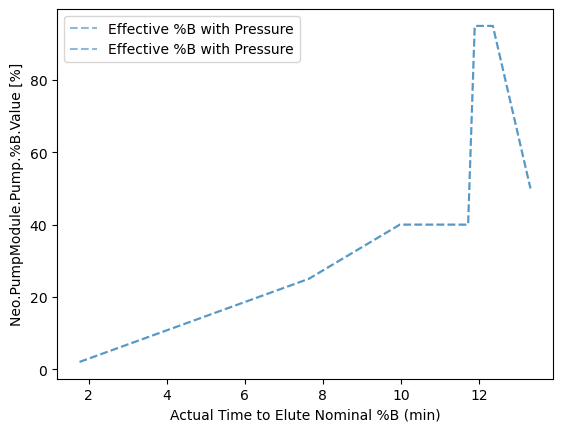

In [30]:
sns.lineplot(data=trap_method_with_pressure.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B with Pressure', linestyle='--', color='tab:blue', alpha=0.5)
sns.lineplot(data=trap_method_extra.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B with Pressure', linestyle='--', color='tab:blue', alpha=0.5)

In [22]:
# Set up dead volume values for testing
trap_dead_volume = 150 * 8.8  # From previous example
direct_dead_volume = 825      # Direct injection dead volume

# ML13

In [9]:
prot_df_ml13 = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/13ML_B25V35_BrukerSpecLib_noNorm/dia-quant-output/report.pg_matrix.tsv", sep='\t')

In [10]:
psm_df_ml13 = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/13ML_B25V35_BrukerSpecLib_noNorm/dia-quant-output/report.pr_matrix.tsv", sep='\t')

In [12]:
# Process each method separately with unique column names
for meth in ['ML13B25', 'ML13V35']:  # Fixed method names
    column_names = prot_df_ml13.columns[prot_df_ml13.columns.str.contains(meth)]
    columns = prot_df_ml13[column_names]
    
    # Create method-specific column names to avoid overwriting
    prot_df_ml13.loc[:, f'{meth}_#Replicates'] = columns.notna().sum(axis=1)
    
    prot_df_ml13.loc[:, f'{meth}_%CV'] = columns.std(axis=1) / columns.mean(axis=1) * 100
    prot_df_ml13.loc[:, f'{meth}_Average'] = columns.mean(axis=1)
    prot_df_ml13.loc[:, f'{meth}_Log2Average'] = np.log2(columns.mean(axis=1))


<Axes: xlabel='ML13B25_#Replicates', ylabel='Proportion'>

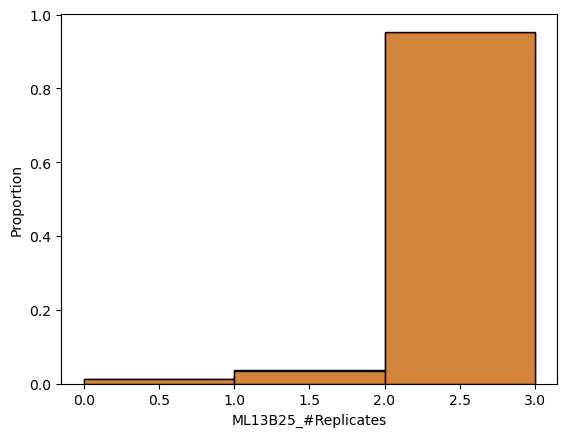

In [17]:
sns.histplot(prot_df_ml13['ML13B25_#Replicates'], binwidth=1, stat='proportion')
sns.histplot(prot_df_ml13['ML13V35_#Replicates'], binwidth=1, stat='proportion')

In [ ]:
layerdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1,
           quantity_layer='Precursor.Quantity', 
           log2=True) 

In [55]:
lccollection.methods

{'33ML7mlInlineZZA15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a871f150>,
 '28ML6mlInlineDIWashLWF24A15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a85fa450>,
 '33ML6mlInlinePW951mA15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33aa2f1350>,
 '33ML7mlInlineA15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a849d750>,
 '23p7ZSlowDropCurve1ML6mlInlineDIWashLWF12A15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a86061d0>,
 '36ML6mlInlineDIWashLA15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a8606650>,
 '26mLZZControlledCatchPW18Curve4ML6mlInlineDIWashLWF12A15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a85a5350>,
 '35ML6mlInlineA15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33aa937990>,
 '24p8ZSlowDropCurve3ML6mlInlineDIWashLWF12A15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x7f33a84ef9d0>,
 '35ML7mlInlineW95A15TrapNS5': <parsers.vneometh.vneo_method.VNeoMethod at 0x

Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]'],
      dtype='object')


<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

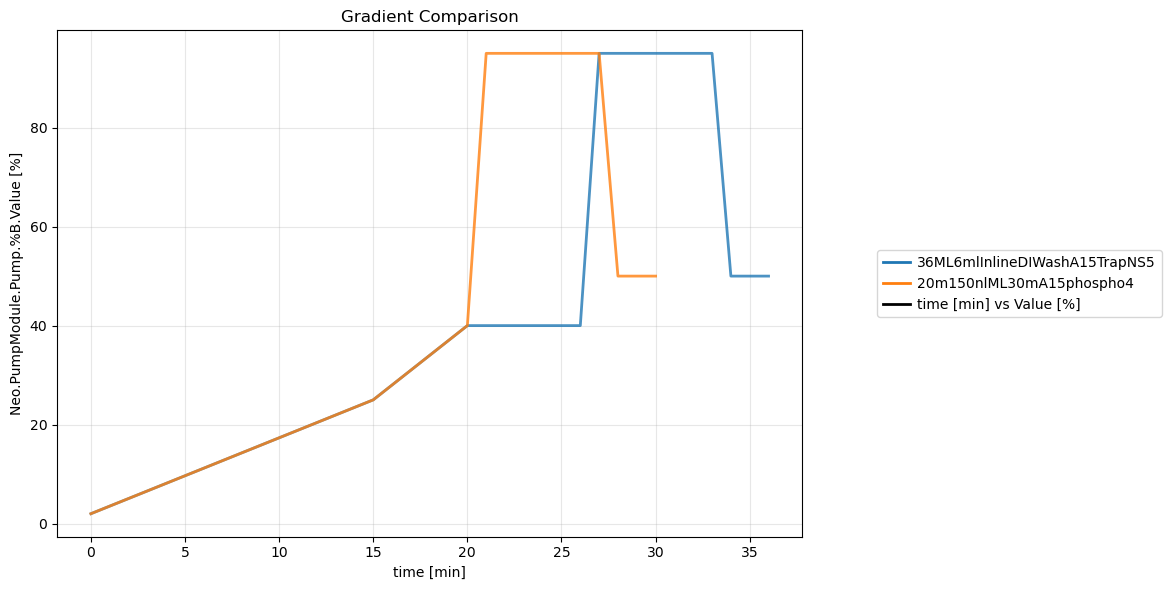

In [56]:
lccollection.plot_gradients(['36ML6mlInlineDIWashA15TrapNS5', '20m150nlML30mA15phospho4'], 
                            x_cols = 'time [min]', 
                            y_cols = 'Neo.PumpModule.Pump.%B.Value [%]',
                            twin_axes=True)

In [80]:
trap = lccollection.methods['36ML6mlInlineDIWashA15TrapNS5'].copy().adjusted_elution(
    in_place=False,
    dead_volume=11.5 * 150, 
    direct_only = 5.5 * 150,
    )
direct = lccollection.methods['20m150nlML30mA15phospho4'].copy().adjusted_elution(
    in_place=False,
    dead_volume=5* 150)

Trapped volume: 900 nL
Trapped %B range: N/A


<Axes: xlabel='Actual Time to Elute Nominal %B (min)', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

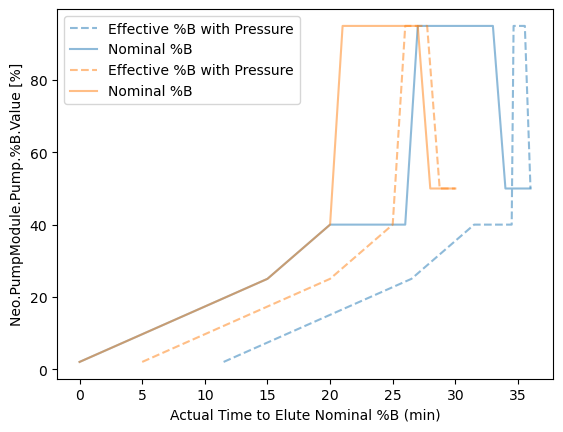

In [81]:
sns.lineplot(data=trap.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B with Pressure', linestyle='--', color='tab:blue', alpha=0.5)
sns.lineplot(data=trap.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', label='Nominal %B', color='tab:blue', alpha=0.5)

sns.lineplot(data=direct.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', label='Effective %B with Pressure', linestyle='--', color='tab:orange', alpha=0.5)
sns.lineplot(data=direct.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', label='Nominal %B', color='tab:orange', alpha=0.5)


In [15]:
trap_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/TE_33ML_5ng/dia-quant-output/report.pg_matrix.tsv", sep='\t')
direct_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/DI_5ng/dia-quant-output/report.pg_matrix.tsv", sep='\t')

In [ ]:
trap_pr_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/TE_33ML_5ng/dia-quant-output/report.pr_matrix.tsv", sep='\t')
direct_pr_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/DI_5ng/dia-quant-output/report.pr_matrix.tsv", sep='\t')

In [19]:
merged = trap_df.merge(direct_df)

In [29]:
trap_cols = merged.columns[merged.columns.str.contains('33ML6mlInlineA15TrapNS5')]
direct_cols = merged.columns[merged.columns.str.contains('20m150nlML30mA15phospho4')]

In [30]:
for group, cols in {'trap': trap_cols, 'direct': direct_cols}.items():
    merged[f'{group} #Reps'] = (merged[cols] > 0).sum(axis=1)

    merged[f'{group} %CV'] = merged[cols].std(axis=1) / merged[cols].mean(axis=1) * 100
    merged[f'{group} Average'] = merged[cols].mean(axis=1)
    merged[f'{group} Log2Average'] = np.log2(merged[cols].mean(axis=1)) 


Original proteins: 6513
After filtering (>1 replicate in both methods): 6339


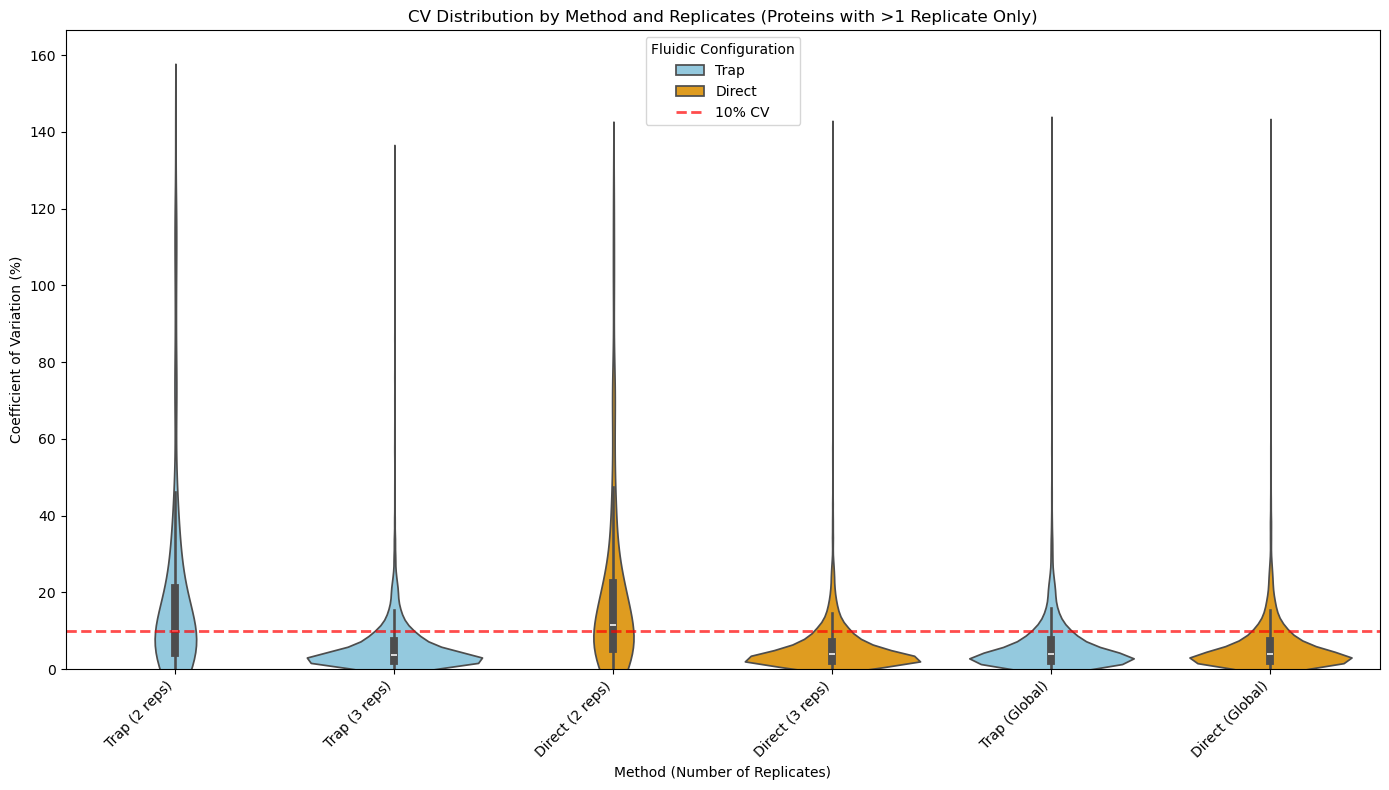


Summary statistics:
Trap methods CV range: 0.0 - 140.8%
Direct methods CV range: 0.0 - 140.4%


In [50]:
# Filter out proteins only identified in 1 replicate
filtered_merged = merged[(merged['trap #Reps'] > 1) & (merged['direct #Reps'] > 1)].copy()

print(f"Original proteins: {len(merged)}")
print(f"After filtering (>1 replicate in both methods): {len(filtered_merged)}")

# Create single plot with all violin plots
fig, ax = plt.subplots(figsize=(14, 8))

# Create data for plotting with method and replicate grouping
plot_data = []

# Add trap CV data grouped by number of replicates
for nreps in sorted(filtered_merged['trap #Reps'].unique()):
    subset = filtered_merged[filtered_merged['trap #Reps'] == nreps]
    for cv_val in subset['trap %CV'].dropna():
        plot_data.append({
            'CV': cv_val,
            'Method': f'Trap ({nreps} reps)',
            'Method_Type': 'Trap',
            'Replicates': nreps
        })

# Add direct CV data grouped by number of replicates  
for nreps in sorted(filtered_merged['direct #Reps'].unique()):
    subset = filtered_merged[filtered_merged['direct #Reps'] == nreps]
    for cv_val in subset['direct %CV'].dropna():
        plot_data.append({
            'CV': cv_val,
            'Method': f'Direct ({nreps} reps)',
            'Method_Type': 'Direct',
            'Replicates': nreps
        })

# Add global CVs for each method
global_trap_cv = filtered_merged['trap %CV'].dropna()
global_direct_cv = filtered_merged['direct %CV'].dropna()

for cv_val in global_trap_cv:
    plot_data.append({
        'CV': cv_val,
        'Method': 'Trap (Global)',
        'Method_Type': 'Trap',
        'Replicates': 'All'
    })

for cv_val in global_direct_cv:
    plot_data.append({
        'CV': cv_val,
        'Method': 'Direct (Global)',
        'Method_Type': 'Direct', 
        'Replicates': 'All'
    })

plot_df = pd.DataFrame(plot_data)

# Create violin plot with different colors for trap vs direct
# Define custom palette for trap (blue) vs direct (orange)
method_palette = {'Trap': 'skyblue', 'Direct': 'orange'}

sns.violinplot(data=plot_df, x='Method', y='CV', hue='Method_Type', 
               palette=method_palette, ax=ax)

# Add 10% CV reference line
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10% CV', linewidth=2)

# Set y-axis to start at 0
ax.set_ylim(bottom=0)

ax.set_title('CV Distribution by Method and Replicates (Proteins with >1 Replicate Only)')
ax.set_xlabel('Method (Number of Replicates)')
ax.set_ylabel('Coefficient of Variation (%)')

# Combine legends for method types and reference line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Fluidic Configuration')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nSummary statistics:")
print(f"Trap methods CV range: {global_trap_cv.min():.1f} - {global_trap_cv.max():.1f}%")
print(f"Direct methods CV range: {global_direct_cv.min():.1f} - {global_direct_cv.max():.1f}%")

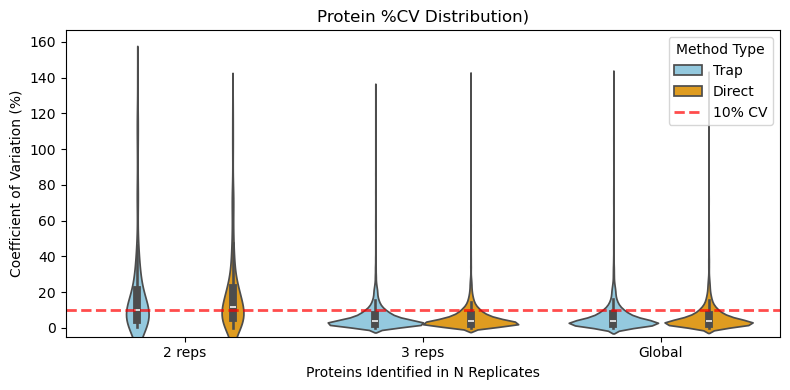

In [52]:
# Alternative grouped visualization - paired violins for 2 reps, 3 reps, and global
fig, ax = plt.subplots(figsize=(8, 4))

# Create data grouped by replicate categories
grouped_data = []

# Define the categories we want to show
categories = ['2 reps', '3 reps', 'Global']

for category in categories:
    if category == '2 reps':
        trap_data = filtered_merged[filtered_merged['trap #Reps'] == 2]['trap %CV'].dropna()
        direct_data = filtered_merged[filtered_merged['direct #Reps'] == 2]['direct %CV'].dropna()
    elif category == '3 reps':
        trap_data = filtered_merged[filtered_merged['trap #Reps'] == 3]['trap %CV'].dropna()
        direct_data = filtered_merged[filtered_merged['direct #Reps'] == 3]['direct %CV'].dropna()
    else:  # Global
        trap_data = filtered_merged['trap %CV'].dropna()
        direct_data = filtered_merged['direct %CV'].dropna()
    
    # Add trap data
    for cv_val in trap_data:
        grouped_data.append({
            'CV': cv_val,
            'Category': category,
            'Method': 'Trap'
        })
    
    # Add direct data
    for cv_val in direct_data:
        grouped_data.append({
            'CV': cv_val,
            'Category': category,
            'Method': 'Direct'
        })

grouped_df = pd.DataFrame(grouped_data)

# Create paired violin plot
method_palette = {'Trap': 'skyblue', 'Direct': 'orange'}
sns.violinplot(data=grouped_df, x='Category', y='CV', hue='Method', 
               palette=method_palette, ax=ax)

# Add 10% CV reference line
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10% CV', linewidth=2)

# Set y-axis to start at 0
ax.set_ylim(bottom=-5)

ax.set_title('Protein %CV Distribution)')
ax.set_xlabel('Proteins Identified in N Replicates')
ax.set_ylabel('Coefficient of Variation (%)')

# Update legend to include the 10% CV line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels + ['10% CV'], title='Method Type')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2928516/2285657145.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=global_cv_df, x='Method', y='CV',


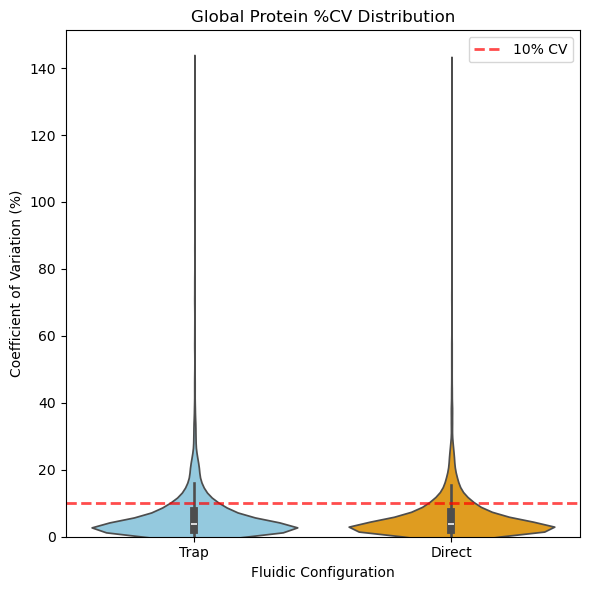

Global CV Statistics:
Trap: 6.4 ± 9.1% (n=6339)
Direct: 6.2 ± 8.4% (n=6339)
matplotlib-venn not available, installing...
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=223d47f483eff7c2f842500b3a06ea47e7b8b5a2906cb3a69fde87e25dd773f4
  Stored in directory: /home/eileen.wang/.cache/pip/wheels/c4/16/4a/93374cd955bbe0553a8ce74db7f0fbd5fcc876e19fb78bd601
Successfully built matplotlib-venn


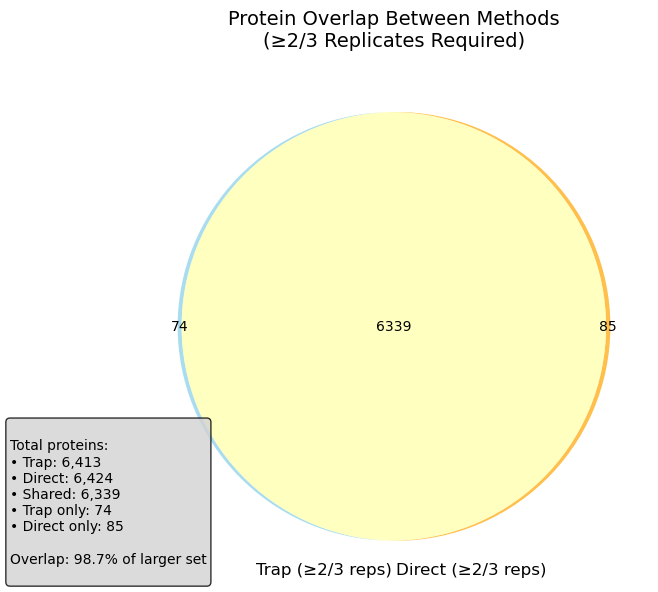


Venn Diagram Statistics:
Trap proteins (≥2/3 reps): 6,413
Direct proteins (≥2/3 reps): 6,424
Shared proteins: 6,339
Trap-only proteins: 74
Direct-only proteins: 85
Jaccard index (overlap/union): 0.976


In [ ]:
# Global CV comparison only
fig, ax = plt.subplots(figsize=(6, 6))

# Create data with only global CVs
global_cv_data = []

# Add trap global CVs
for cv_val in filtered_merged['trap %CV'].dropna():
    global_cv_data.append({
        'CV': cv_val,
        'Method': 'Trap'
    })

# Add direct global CVs  
for cv_val in filtered_merged['direct %CV'].dropna():
    global_cv_data.append({
        'CV': cv_val,
        'Method': 'Direct'
    })

global_cv_df = pd.DataFrame(global_cv_data)

# Create violin plot
method_palette = {'Trap': 'skyblue', 'Direct': 'orange'}
sns.violinplot(data=global_cv_df, x='Method', y='CV', 
               palette=method_palette, ax=ax)

# Add 10% CV reference line
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10% CV', linewidth=2)

# Set y-axis to start at 0
ax.set_ylim(bottom=0)

ax.set_title('Global Protein %CV Distribution')
ax.set_xlabel('Fluidic Configuration')
ax.set_ylabel('Coefficient of Variation (%)')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics for global CVs
print(f"Global CV Statistics:")
print(f"Trap: {filtered_merged['trap %CV'].mean():.1f} ± {filtered_merged['trap %CV'].std():.1f}% (n={len(filtered_merged['trap %CV'].dropna())})")
print(f"Direct: {filtered_merged['direct %CV'].mean():.1f} ± {filtered_merged['direct %CV'].std():.1f}% (n={len(filtered_merged['direct %CV'].dropna())})")



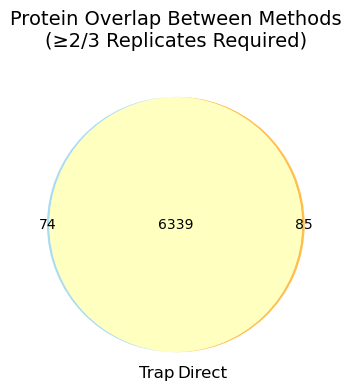


Venn Diagram Statistics:
Trap proteins: 6,413
Direct proteins: 6,424
Shared proteins: 6,339
Trap-only proteins: 74
Direct-only proteins: 85
Jaccard index (overlap/union): 0.976


In [62]:
# Venn diagram of shared proteins (≥2/3 replicates)
try:
    from matplotlib_venn import venn2
    venn_available = True
except ImportError:
    print("matplotlib-venn not available, installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'matplotlib-venn'])
    from matplotlib_venn import venn2
    venn_available = True

# Filter proteins quantified in at least 2/3 replicates for each method
trap_proteins = set(merged[merged['trap #Reps'] >= 2].index)
direct_proteins = set(merged[merged['direct #Reps'] >= 2].index)

# Create Venn diagram
fig, ax = plt.subplots(figsize=(4, 4))

venn = venn2([trap_proteins, direct_proteins], 
             set_labels=('Trap', 'Direct'),
             set_colors=('skyblue', 'orange'),
             alpha=0.7,
             ax=ax)

# Add statistics text
overlap = len(trap_proteins & direct_proteins)
trap_only = len(trap_proteins - direct_proteins)
direct_only = len(direct_proteins - trap_proteins)
total_trap = len(trap_proteins)
total_direct = len(direct_proteins)

ax.set_title(f'Protein Overlap Between Methods\n(≥2/3 Replicates Required)', fontsize=14, pad=20)

# # Add text with statistics
# stats_text = f"""
# Total proteins:
# • Trap: {total_trap:,}
# • Direct: {total_direct:,}
# • Shared: {overlap:,}
# • Trap only: {trap_only:,}
# • Direct only: {direct_only:,}

# Overlap: {overlap/max(total_trap, total_direct)*100:.1f}% of larger set
# """

# plt.figtext(0.02, 0.02, stats_text, fontsize=10, verticalalignment='bottom',
#             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nVenn Diagram Statistics:")
print(f"Trap proteins: {total_trap:,}")
print(f"Direct proteins: {total_direct:,}")
print(f"Shared proteins: {overlap:,}")
print(f"Trap-only proteins: {trap_only:,}")  
print(f"Direct-only proteins: {direct_only:,}")
print(f"Jaccard index (overlap/union): {overlap/(total_trap + total_direct - overlap):.3f}")

# Protein Count by Replicate

Bar chart showing the number of proteins identified in each replicate for trap vs direct injection methods.

In [65]:
# Count proteins identified in each replicate
replicate_counts = []

# Count proteins for each trap replicate
for i, col in enumerate(trap_cols):
    protein_count = (merged[col] > 0).sum()
    replicate_counts.append({
        'Method': 'Trap',
        'Replicate': f'Rep {i+1}',
        'Replicate_Full': col,
        'Protein_Count': protein_count
    })

# Count proteins for each direct replicate  
for i, col in enumerate(direct_cols):
    protein_count = (merged[col] > 0).sum()
    replicate_counts.append({
        'Method': 'Direct',
        'Replicate': f'Rep {i+1}',
        'Replicate_Full': col,
        'Protein_Count': protein_count
    })

# Convert to DataFrame
replicate_df = pd.DataFrame(replicate_counts)
print(f"Trap columns: {len(trap_cols)}")
print(f"Direct columns: {len(direct_cols)}")
print("\nProtein counts per replicate:")
print(replicate_df)

Trap columns: 3
Direct columns: 3

Protein counts per replicate:
   Method Replicate                                     Replicate_Full  \
0    Trap     Rep 1  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
1    Trap     Rep 2  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
2    Trap     Rep 3  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
3  Direct     Rep 1  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   
4  Direct     Rep 2  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   
5  Direct     Rep 3  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   

   Protein_Count  
0           6347  
1           6368  
2           6351  
3           6332  
4           6387  
5           6376  



Summary statistics:
               mean        std   min   max
Method                                    
Direct  6365.000000  29.103264  6332  6387
Trap    6355.333333  11.150486  6347  6368


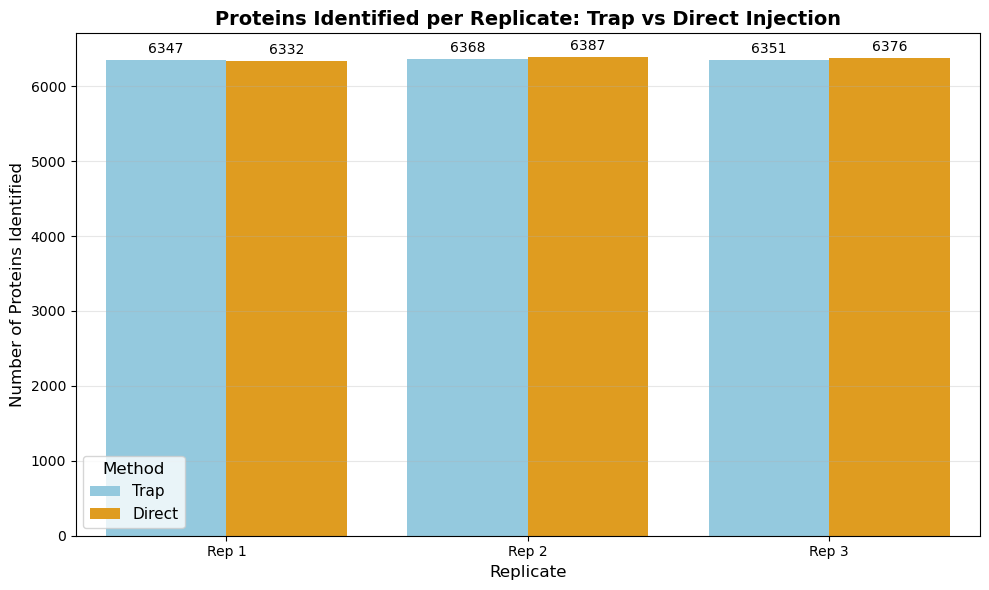

In [66]:
# Create bar chart
plt.figure(figsize=(10, 6))

# Create the bar plot
ax = sns.barplot(data=replicate_df, x='Replicate', y='Protein_Count', hue='Method', 
                 palette={'Trap': 'skyblue', 'Direct': 'orange'})

plt.title('Proteins Identified per Replicate: Trap vs Direct Injection', fontsize=14, fontweight='bold')
plt.xlabel('Replicate', fontsize=12)
plt.ylabel('Number of Proteins Identified', fontsize=12)
plt.legend(title='Method', title_fontsize=12, fontsize=11)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

# Adjust layout and grid
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Print summary statistics
print("\nSummary statistics:")
summary_stats = replicate_df.groupby('Method')['Protein_Count'].agg(['mean', 'std', 'min', 'max'])
print(summary_stats)

plt.show()

In [67]:
# Additional analysis: difference between methods
mean_difference = replicate_df[replicate_df['Method'] == 'Direct']['Protein_Count'].mean() - \
                 replicate_df[replicate_df['Method'] == 'Trap']['Protein_Count'].mean()

print(f"\nComparison between methods:")
print(f"Average proteins identified:")
print(f"  - Direct injection: {replicate_df[replicate_df['Method'] == 'Direct']['Protein_Count'].mean():.1f}")
print(f"  - Trap injection: {replicate_df[replicate_df['Method'] == 'Trap']['Protein_Count'].mean():.1f}")
print(f"  - Difference (Direct - Trap): {mean_difference:.1f} proteins")
print(f"  - Relative difference: {(mean_difference/replicate_df[replicate_df['Method'] == 'Trap']['Protein_Count'].mean()*100):.2f}%")

# Reproducibility analysis
trap_cv = replicate_df[replicate_df['Method'] == 'Trap']['Protein_Count'].std() / \
          replicate_df[replicate_df['Method'] == 'Trap']['Protein_Count'].mean() * 100
direct_cv = replicate_df[replicate_df['Method'] == 'Direct']['Protein_Count'].std() / \
            replicate_df[replicate_df['Method'] == 'Direct']['Protein_Count'].mean() * 100

print(f"\nReproducibility (CV of protein counts):")
print(f"  - Trap method: {trap_cv:.2f}%")
print(f"  - Direct method: {direct_cv:.2f}%")


Comparison between methods:
Average proteins identified:
  - Direct injection: 6365.0
  - Trap injection: 6355.3
  - Difference (Direct - Trap): 9.7 proteins
  - Relative difference: 0.15%

Reproducibility (CV of protein counts):
  - Trap method: 0.18%
  - Direct method: 0.46%


# Protein Replicate Distribution

Stacked bar chart showing how proteins are distributed across different numbers of replicates for trap vs direct injection methods.

In [71]:
# Calculate cumulative and exclusive replicate counts for both methods
replicate_analysis = {}

for method, rep_col in [('Trap', 'trap #Reps'), ('Direct', 'direct #Reps')]:
    # Count proteins in exactly 1, 2, or 3 replicates (exclusive categories)
    exactly_1 = (merged[rep_col] == 1).sum()
    exactly_2 = (merged[rep_col] == 2).sum() 
    exactly_3 = (merged[rep_col] == 3).sum()
    
    # Count proteins in at least 1, 2, or 3 replicates (cumulative categories)
    at_least_1 = (merged[rep_col] >= 1).sum()
    at_least_2 = (merged[rep_col] >= 2).sum()  
    at_least_3 = (merged[rep_col] >= 3).sum()
    
    total_proteins = len(merged)
    
    replicate_analysis[method] = {
        'exactly_1': exactly_1,
        'exactly_2': exactly_2, 
        'exactly_3': exactly_3,
        'at_least_1': at_least_1,
        'at_least_2': at_least_2,
        'at_least_3': at_least_3,
        'total_proteins': total_proteins
    }
    
    print(f"\n{method} Method Analysis:")
    print(f"  Total proteins in dataset: {total_proteins}")
    print(f"  Proteins in ≥1 replicate: {at_least_1} ({at_least_1/total_proteins*100:.1f}%)")
    print(f"  Proteins in ≥2 replicates: {at_least_2} ({at_least_2/total_proteins*100:.1f}%)")  
    print(f"  Proteins in all 3 replicates: {at_least_3} ({at_least_3/total_proteins*100:.1f}%)")
    print(f"  Breakdown:")
    print(f"    Exactly 1 replicate: {exactly_1}")
    print(f"    Exactly 2 replicates: {exactly_2}")
    print(f"    All 3 replicates: {exactly_3}")
    
# Verify our counts add up
for method in replicate_analysis:
    data = replicate_analysis[method]
    total_check = data['exactly_1'] + data['exactly_2'] + data['exactly_3']
    print(f"\n{method} total check: {total_check} (should equal proteins in ≥1 replicate: {data['at_least_1']})")


Trap Method Analysis:
  Total proteins in dataset: 6513
  Proteins in ≥1 replicate: 6513 (100.0%)
  Proteins in ≥2 replicates: 6413 (98.5%)
  Proteins in all 3 replicates: 6140 (94.3%)
  Breakdown:
    Exactly 1 replicate: 100
    Exactly 2 replicates: 273
    All 3 replicates: 6140

Direct Method Analysis:
  Total proteins in dataset: 6513
  Proteins in ≥1 replicate: 6513 (100.0%)
  Proteins in ≥2 replicates: 6424 (98.6%)
  Proteins in all 3 replicates: 6158 (94.5%)
  Breakdown:
    Exactly 1 replicate: 89
    Exactly 2 replicates: 266
    All 3 replicates: 6158

Trap total check: 6513 (should equal proteins in ≥1 replicate: 6513)

Direct total check: 6513 (should equal proteins in ≥1 replicate: 6513)


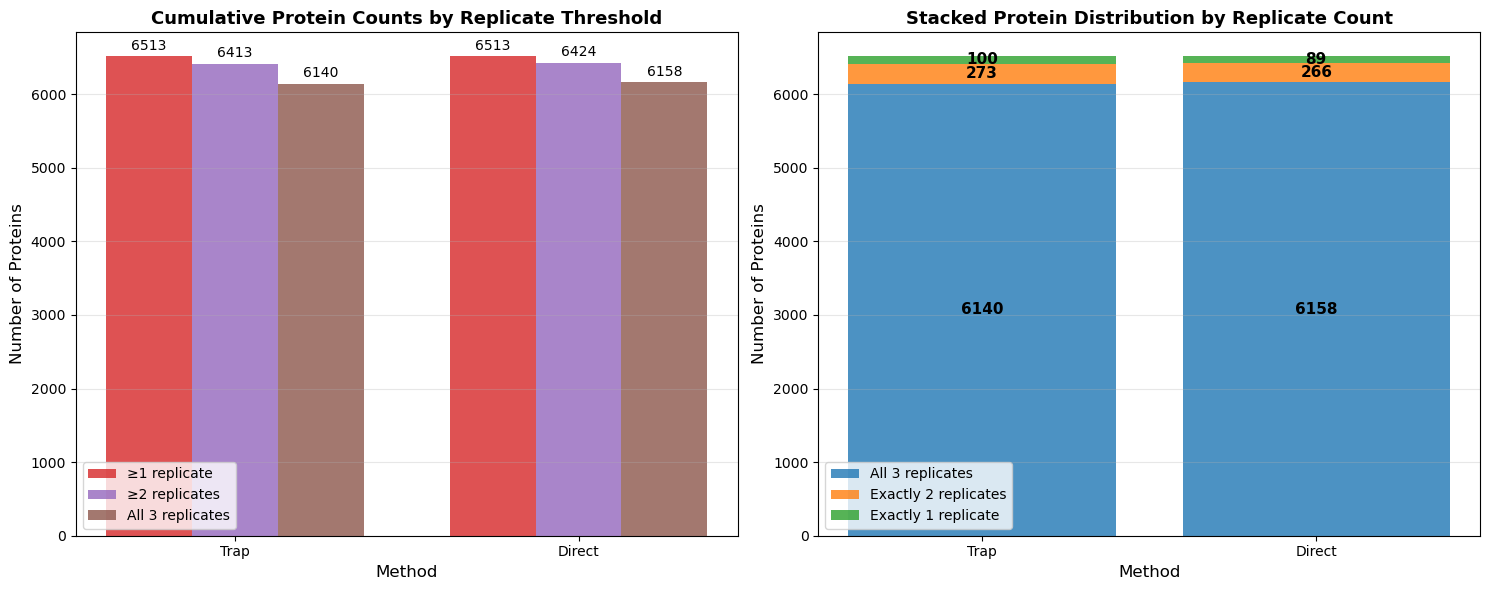

In [77]:
# Create stacked bar charts showing both cumulative and exclusive replicate distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Cumulative counts (≥1, ≥2, =3 replicates)
methods = ['Trap', 'Direct']
at_least_1 = [replicate_analysis['Trap']['at_least_1'], replicate_analysis['Direct']['at_least_1']]
at_least_2 = [replicate_analysis['Trap']['at_least_2'], replicate_analysis['Direct']['at_least_2']]  
all_3 = [replicate_analysis['Trap']['at_least_3'], replicate_analysis['Direct']['at_least_3']]

x = np.arange(len(methods))
width = 0.25

# Get tab10 colors
tab10_colors = plt.cm.tab10.colors

bars1 = ax1.bar(x - width, at_least_1, width, label='≥1 replicate', color=tab10_colors[3], alpha=0.8)
bars2 = ax1.bar(x, at_least_2, width, label='≥2 replicates', color=tab10_colors[4], alpha=0.8)
bars3 = ax1.bar(x + width, all_3, width, label='All 3 replicates', color=tab10_colors[5], alpha=0.8)

ax1.set_xlabel('Method', fontsize=12)
ax1.set_ylabel('Number of Proteins', fontsize=12)
ax1.set_title('Cumulative Protein Counts by Replicate Threshold', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Chart 2: Exclusive counts (exactly 1, exactly 2, exactly 3)
exactly_1 = [replicate_analysis['Trap']['exactly_1'], replicate_analysis['Direct']['exactly_1']]
exactly_2 = [replicate_analysis['Trap']['exactly_2'], replicate_analysis['Direct']['exactly_2']]
exactly_3 = [replicate_analysis['Trap']['exactly_3'], replicate_analysis['Direct']['exactly_3']]

# Create stacked bar chart with flipped order (3 replicates on bottom)
# Get tab10 colors
tab10_colors = plt.cm.tab10.colors

bottom_2 = exactly_3  # 2 replicates sits on top of 3 replicates
bottom_1 = [exactly_3[i] + exactly_2[i] for i in range(len(exactly_3))]  # 1 replicate sits on top

bars3_stack = ax2.bar(methods, exactly_3, label='All 3 replicates', color=tab10_colors[0], alpha=0.8)
bars2_stack = ax2.bar(methods, exactly_2, bottom=bottom_2, label='Exactly 2 replicates', color=tab10_colors[1], alpha=0.8)  
bars1_stack = ax2.bar(methods, exactly_1, bottom=bottom_1, label='Exactly 1 replicate', color=tab10_colors[2], alpha=0.8)

ax2.set_xlabel('Method', fontsize=12)
ax2.set_ylabel('Number of Proteins', fontsize=12)  
ax2.set_title('Stacked Protein Distribution by Replicate Count', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on stacked segments (updated for flipped order)
for i, method in enumerate(methods):
    # Label for exactly 3 (bottom segment)
    y3 = exactly_3[i] / 2
    ax2.text(i, y3, f'{exactly_3[i]}', ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Label for exactly 2 (middle segment)
    y2 = exactly_3[i] + exactly_2[i] / 2
    ax2.text(i, y2, f'{exactly_2[i]}', ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Label for exactly 1 (top segment)
    y1 = exactly_3[i] + exactly_2[i] + exactly_1[i] / 2
    ax2.text(i, y1, f'{exactly_1[i]}', ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [78]:
# Summary analysis of replicate consistency
print("=== REPLICATE CONSISTENCY SUMMARY ===\n")

for method in ['Trap', 'Direct']:
    data = replicate_analysis[method]
    total = data['total_proteins']
    
    print(f"{method} Method:")
    print(f"  Proteins with excellent reproducibility (3/3 replicates): {data['exactly_3']:,} ({data['exactly_3']/total*100:.1f}%)")
    print(f"  Proteins with good reproducibility (2/3 replicates): {data['exactly_2']:,} ({data['exactly_2']/total*100:.1f}%)")  
    print(f"  Proteins with poor reproducibility (1/3 replicates): {data['exactly_1']:,} ({data['exactly_1']/total*100:.1f}%)")
    print(f"  High-confidence proteins (≥2/3 replicates): {data['at_least_2']:,} ({data['at_least_2']/total*100:.1f}%)")
    print()

# Compare methods
trap_robust = replicate_analysis['Trap']['at_least_2']
direct_robust = replicate_analysis['Direct']['at_least_2']
trap_excellent = replicate_analysis['Trap']['exactly_3'] 
direct_excellent = replicate_analysis['Direct']['exactly_3']

print("=== METHOD COMPARISON ===")
print(f"High-confidence proteins (≥2/3 replicates):")
print(f"  Trap: {trap_robust:,} proteins")
print(f"  Direct: {direct_robust:,} proteins") 
print(f"  Difference: {direct_robust - trap_robust:,} proteins ({((direct_robust-trap_robust)/trap_robust*100):+.2f}%)")
print()
print(f"Excellent reproducibility (3/3 replicates):")
print(f"  Trap: {trap_excellent:,} proteins")
print(f"  Direct: {direct_excellent:,} proteins")
print(f"  Difference: {direct_excellent - trap_excellent:,} proteins ({((direct_excellent-trap_excellent)/trap_excellent*100):+.2f}%)")

# Calculate reproducibility metrics
trap_repro_score = (replicate_analysis['Trap']['exactly_3'] * 3 + 
                   replicate_analysis['Trap']['exactly_2'] * 2 + 
                   replicate_analysis['Trap']['exactly_1'] * 1) / (replicate_analysis['Trap']['total_proteins'] * 3) * 100

direct_repro_score = (replicate_analysis['Direct']['exactly_3'] * 3 + 
                     replicate_analysis['Direct']['exactly_2'] * 2 + 
                     replicate_analysis['Direct']['exactly_1'] * 1) / (replicate_analysis['Direct']['total_proteins'] * 3) * 100

print(f"\n=== OVERALL REPRODUCIBILITY SCORES ===")
print(f"Trap method: {trap_repro_score:.1f}% (weighted average across replicates)")
print(f"Direct method: {direct_repro_score:.1f}% (weighted average across replicates)")
print(f"Difference: {direct_repro_score - trap_repro_score:+.2f} percentage points")

=== REPLICATE CONSISTENCY SUMMARY ===

Trap Method:
  Proteins with excellent reproducibility (3/3 replicates): 6,140 (94.3%)
  Proteins with good reproducibility (2/3 replicates): 273 (4.2%)
  Proteins with poor reproducibility (1/3 replicates): 100 (1.5%)
  High-confidence proteins (≥2/3 replicates): 6,413 (98.5%)

Direct Method:
  Proteins with excellent reproducibility (3/3 replicates): 6,158 (94.5%)
  Proteins with good reproducibility (2/3 replicates): 266 (4.1%)
  Proteins with poor reproducibility (1/3 replicates): 89 (1.4%)
  High-confidence proteins (≥2/3 replicates): 6,424 (98.6%)

=== METHOD COMPARISON ===
High-confidence proteins (≥2/3 replicates):
  Trap: 6,413 proteins
  Direct: 6,424 proteins
  Difference: 11 proteins (+0.17%)

Excellent reproducibility (3/3 replicates):
  Trap: 6,140 proteins
  Direct: 6,158 proteins
  Difference: 18 proteins (+0.29%)

=== OVERALL REPRODUCIBILITY SCORES ===
Trap method: 97.6% (weighted average across replicates)
Direct method: 97.7% (w

# Precursor-Level Analysis

Repeating the same analyses at the precursor level instead of protein level.

In [84]:
# Load precursor-level data (pr_matrix files)
trap_pr_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/TE_33ML_5ng/dia-quant-output/report.pr_matrix.tsv", sep='\t')
direct_pr_df = pd.read_csv("/hpc/projects/mass_spec/eileenwang/VNTT/Searches/13ML/DI_5ng/dia-quant-output/report.pr_matrix.tsv", sep='\t')

print(f"Trap precursor data shape: {trap_pr_df.shape}")
print(f"Direct precursor data shape: {direct_pr_df.shape}")

# Merge the datasets
merged_pr = trap_pr_df.merge(direct_pr_df)
print(f"Merged precursor data shape: {merged_pr.shape}")

# Get the same column patterns for precursor data
trap_pr_cols = merged_pr.columns[merged_pr.columns.str.contains('33ML6mlInlineA15TrapNS5')]
direct_pr_cols = merged_pr.columns[merged_pr.columns.str.contains('20m150nlML30mA15phospho4')]

print(f"Trap precursor columns: {len(trap_pr_cols)}")
print(f"Direct precursor columns: {len(direct_pr_cols)}")
print(f"Total precursors in merged dataset: {len(merged_pr)}")

Trap precursor data shape: (69670, 13)
Direct precursor data shape: (73000, 13)
Merged precursor data shape: (59670, 16)
Trap precursor columns: 3
Direct precursor columns: 3
Total precursors in merged dataset: 59670


# Precursor Count by Replicate

Bar chart showing the number of precursors identified in each replicate for trap vs direct injection methods.

In [85]:
# Count precursors identified in each replicate
precursor_counts = []

# Count precursors for each trap replicate
for i, col in enumerate(trap_pr_cols):
    precursor_count = (merged_pr[col] > 0).sum()
    precursor_counts.append({
        'Method': 'Trap',
        'Replicate': f'Rep {i+1}',
        'Replicate_Full': col,
        'Precursor_Count': precursor_count
    })

# Count precursors for each direct replicate  
for i, col in enumerate(direct_pr_cols):
    precursor_count = (merged_pr[col] > 0).sum()
    precursor_counts.append({
        'Method': 'Direct',
        'Replicate': f'Rep {i+1}',
        'Replicate_Full': col,
        'Precursor_Count': precursor_count
    })

# Convert to DataFrame
precursor_replicate_df = pd.DataFrame(precursor_counts)
print(f"Trap precursor columns: {len(trap_pr_cols)}")
print(f"Direct precursor columns: {len(direct_pr_cols)}")
print("\nPrecursor counts per replicate:")
print(precursor_replicate_df)

Trap precursor columns: 3
Direct precursor columns: 3

Precursor counts per replicate:
   Method Replicate                                     Replicate_Full  \
0    Trap     Rep 1  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
1    Trap     Rep 2  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
2    Trap     Rep 3  /hpc/projects/mass_spec/projects/VNTT003/raw_d...   
3  Direct     Rep 1  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   
4  Direct     Rep 2  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   
5  Direct     Rep 3  /hpc/projects/mass_spec/projects/VNTT001/raw_d...   

   Precursor_Count  
0            52864  
1            53101  
2            52250  
3            51551  
4            53282  
5            53217  



Summary statistics:
                mean         std    min    max
Method                                        
Direct  52683.333333  981.167842  51551  53282
Trap    52738.333333  439.197374  52250  53101


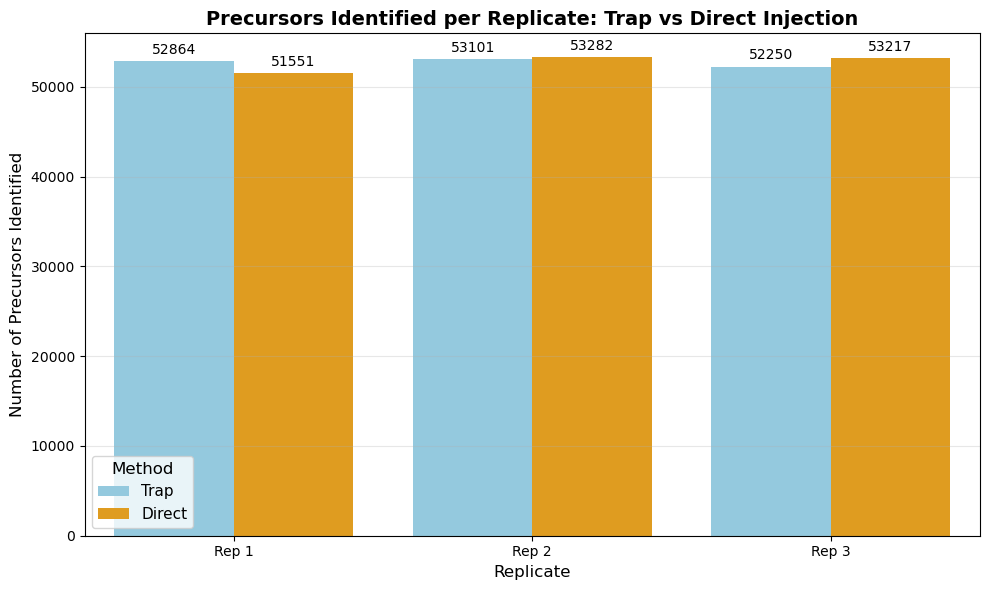

In [91]:
# Create bar chart for precursor counts
plt.figure(figsize=(10, 6))

# Create the bar plot
ax = sns.barplot(data=precursor_replicate_df, x='Replicate', y='Precursor_Count', hue='Method', 
                 palette={'Trap': 'skyblue', 'Direct': 'orange'})

plt.title('Precursors Identified per Replicate: Trap vs Direct Injection', fontsize=14, fontweight='bold')
plt.xlabel('Replicate', fontsize=12)
plt.ylabel('Number of Precursors Identified', fontsize=12)
plt.legend(title='Method', title_fontsize=12, fontsize=11)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

# Adjust layout and grid
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Print summary statistics
print("\nSummary statistics:")
precursor_summary_stats = precursor_replicate_df.groupby('Method')['Precursor_Count'].agg(['mean', 'std', 'min', 'max'])
print(precursor_summary_stats)

plt.show()

# Precursor Replicate Distribution

Stacked bar chart showing how precursors are distributed across different numbers of replicates for trap vs direct injection methods.

In [92]:
# Add replicate count columns for precursors
for group, cols in {'trap': trap_pr_cols, 'direct': direct_pr_cols}.items():
    merged_pr[f'{group} #Reps'] = (merged_pr[cols] > 0).sum(axis=1)

# Calculate cumulative and exclusive replicate counts for precursors
precursor_replicate_analysis = {}

for method, rep_col in [('Trap', 'trap #Reps'), ('Direct', 'direct #Reps')]:
    # Count precursors in exactly 1, 2, or 3 replicates (exclusive categories)
    exactly_1 = (merged_pr[rep_col] == 1).sum()
    exactly_2 = (merged_pr[rep_col] == 2).sum() 
    exactly_3 = (merged_pr[rep_col] == 3).sum()
    
    # Count precursors in at least 1, 2, or 3 replicates (cumulative categories)
    at_least_1 = (merged_pr[rep_col] >= 1).sum()
    at_least_2 = (merged_pr[rep_col] >= 2).sum()  
    at_least_3 = (merged_pr[rep_col] >= 3).sum()
    
    total_precursors = len(merged_pr)
    
    precursor_replicate_analysis[method] = {
        'exactly_1': exactly_1,
        'exactly_2': exactly_2, 
        'exactly_3': exactly_3,
        'at_least_1': at_least_1,
        'at_least_2': at_least_2,
        'at_least_3': at_least_3,
        'total_precursors': total_precursors
    }
    
    print(f"\n{method} Method Analysis (Precursors):")
    print(f"  Total precursors in dataset: {total_precursors}")
    print(f"  Precursors in ≥1 replicate: {at_least_1} ({at_least_1/total_precursors*100:.1f}%)")
    print(f"  Precursors in ≥2 replicates: {at_least_2} ({at_least_2/total_precursors*100:.1f}%)")  
    print(f"  Precursors in all 3 replicates: {at_least_3} ({at_least_3/total_precursors*100:.1f}%)")
    print(f"  Breakdown:")
    print(f"    Exactly 1 replicate: {exactly_1}")
    print(f"    Exactly 2 replicates: {exactly_2}")
    print(f"    All 3 replicates: {exactly_3}")
    
# Verify our counts add up
for method in precursor_replicate_analysis:
    data = precursor_replicate_analysis[method]
    total_check = data['exactly_1'] + data['exactly_2'] + data['exactly_3']
    print(f"\n{method} total check: {total_check} (should equal precursors in ≥1 replicate: {data['at_least_1']})")


Trap Method Analysis (Precursors):
  Total precursors in dataset: 59670
  Precursors in ≥1 replicate: 59670 (100.0%)
  Precursors in ≥2 replicates: 53638 (89.9%)
  Precursors in all 3 replicates: 44907 (75.3%)
  Breakdown:
    Exactly 1 replicate: 6032
    Exactly 2 replicates: 8731
    All 3 replicates: 44907

Direct Method Analysis (Precursors):
  Total precursors in dataset: 59670
  Precursors in ≥1 replicate: 59670 (100.0%)
  Precursors in ≥2 replicates: 53814 (90.2%)
  Precursors in all 3 replicates: 44566 (74.7%)
  Breakdown:
    Exactly 1 replicate: 5856
    Exactly 2 replicates: 9248
    All 3 replicates: 44566

Trap total check: 59670 (should equal precursors in ≥1 replicate: 59670)

Direct total check: 59670 (should equal precursors in ≥1 replicate: 59670)


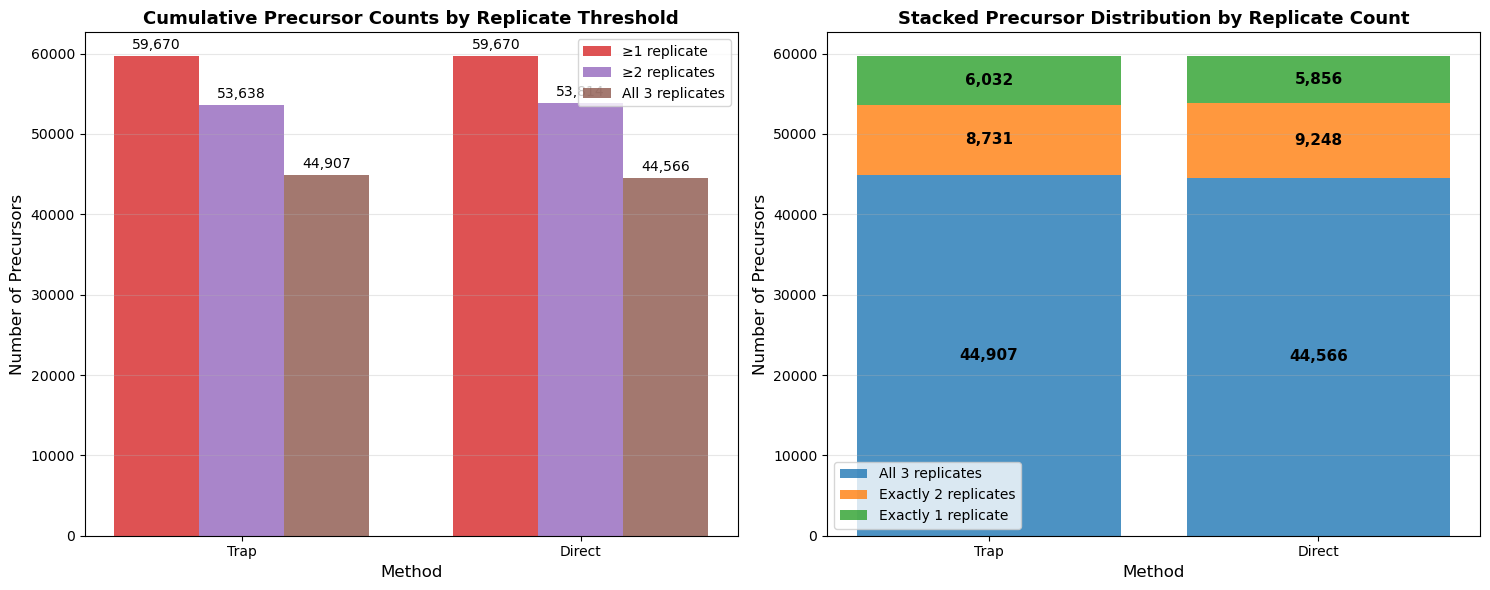

In [93]:
# Create stacked bar charts for precursors showing both cumulative and exclusive replicate distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Cumulative counts (≥1, ≥2, =3 replicates)
methods = ['Trap', 'Direct']
pr_at_least_1 = [precursor_replicate_analysis['Trap']['at_least_1'], precursor_replicate_analysis['Direct']['at_least_1']]
pr_at_least_2 = [precursor_replicate_analysis['Trap']['at_least_2'], precursor_replicate_analysis['Direct']['at_least_2']]  
pr_all_3 = [precursor_replicate_analysis['Trap']['at_least_3'], precursor_replicate_analysis['Direct']['at_least_3']]

x = np.arange(len(methods))
width = 0.25

# Get tab10 colors
tab10_colors = plt.cm.tab10.colors

bars1 = ax1.bar(x - width, pr_at_least_1, width, label='≥1 replicate', color=tab10_colors[3], alpha=0.8)
bars2 = ax1.bar(x, pr_at_least_2, width, label='≥2 replicates', color=tab10_colors[4], alpha=0.8)
bars3 = ax1.bar(x + width, pr_all_3, width, label='All 3 replicates', color=tab10_colors[5], alpha=0.8)

ax1.set_xlabel('Method', fontsize=12)
ax1.set_ylabel('Number of Precursors', fontsize=12)
ax1.set_title('Cumulative Precursor Counts by Replicate Threshold', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 500,
                f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# Chart 2: Exclusive counts (exactly 1, exactly 2, exactly 3) - with flipped order
pr_exactly_1 = [precursor_replicate_analysis['Trap']['exactly_1'], precursor_replicate_analysis['Direct']['exactly_1']]
pr_exactly_2 = [precursor_replicate_analysis['Trap']['exactly_2'], precursor_replicate_analysis['Direct']['exactly_2']]
pr_exactly_3 = [precursor_replicate_analysis['Trap']['exactly_3'], precursor_replicate_analysis['Direct']['exactly_3']]

# Create stacked bar chart with flipped order (3 replicates on bottom)
bottom_2 = pr_exactly_3  # 2 replicates sits on top of 3 replicates
bottom_1 = [pr_exactly_3[i] + pr_exactly_2[i] for i in range(len(pr_exactly_3))]  # 1 replicate sits on top

bars3_stack = ax2.bar(methods, pr_exactly_3, label='All 3 replicates', color=tab10_colors[0], alpha=0.8)
bars2_stack = ax2.bar(methods, pr_exactly_2, bottom=bottom_2, label='Exactly 2 replicates', color=tab10_colors[1], alpha=0.8)  
bars1_stack = ax2.bar(methods, pr_exactly_1, bottom=bottom_1, label='Exactly 1 replicate', color=tab10_colors[2], alpha=0.8)

ax2.set_xlabel('Method', fontsize=12)
ax2.set_ylabel('Number of Precursors', fontsize=12)  
ax2.set_title('Stacked Precursor Distribution by Replicate Count', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on stacked segments (updated for flipped order)
for i, method in enumerate(methods):
    # Label for exactly 3 (bottom segment)
    y3 = pr_exactly_3[i] / 2
    ax2.text(i, y3, f'{pr_exactly_3[i]:,}', ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Label for exactly 2 (middle segment)
    y2 = pr_exactly_3[i] + pr_exactly_2[i] / 2
    ax2.text(i, y2, f'{pr_exactly_2[i]:,}', ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Label for exactly 1 (top segment)
    y1 = pr_exactly_3[i] + pr_exactly_2[i] + pr_exactly_1[i] / 2
    ax2.text(i, y1, f'{pr_exactly_1[i]:,}', ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [90]:
# Summary analysis of precursor replicate consistency
print("=== PRECURSOR REPLICATE CONSISTENCY SUMMARY ===\n")

for method in ['Trap', 'Direct']:
    data = precursor_replicate_analysis[method]
    total = data['total_precursors']
    
    print(f"{method} Method (Precursors):")
    print(f"  Precursors with excellent reproducibility (3/3 replicates): {data['exactly_3']:,} ({data['exactly_3']/total*100:.1f}%)")
    print(f"  Precursors with good reproducibility (2/3 replicates): {data['exactly_2']:,} ({data['exactly_2']/total*100:.1f}%)")  
    print(f"  Precursors with poor reproducibility (1/3 replicates): {data['exactly_1']:,} ({data['exactly_1']/total*100:.1f}%)")
    print(f"  High-confidence precursors (≥2/3 replicates): {data['at_least_2']:,} ({data['at_least_2']/total*100:.1f}%)")
    print()

# Compare methods
trap_robust_pr = precursor_replicate_analysis['Trap']['at_least_2']
direct_robust_pr = precursor_replicate_analysis['Direct']['at_least_2']
trap_excellent_pr = precursor_replicate_analysis['Trap']['exactly_3'] 
direct_excellent_pr = precursor_replicate_analysis['Direct']['exactly_3']

print("=== PRECURSOR METHOD COMPARISON ===")
print(f"High-confidence precursors (≥2/3 replicates):")
print(f"  Trap: {trap_robust_pr:,} precursors")
print(f"  Direct: {direct_robust_pr:,} precursors") 
print(f"  Difference: {direct_robust_pr - trap_robust_pr:,} precursors ({((direct_robust_pr-trap_robust_pr)/trap_robust_pr*100):+.2f}%)")
print()
print(f"Excellent reproducibility (3/3 replicates):")
print(f"  Trap: {trap_excellent_pr:,} precursors")
print(f"  Direct: {direct_excellent_pr:,} precursors")
print(f"  Difference: {direct_excellent_pr - trap_excellent_pr:,} precursors ({((direct_excellent_pr-trap_excellent_pr)/trap_excellent_pr*100):+.2f}%)")

# Calculate reproducibility metrics for precursors
trap_repro_score_pr = (precursor_replicate_analysis['Trap']['exactly_3'] * 3 + 
                      precursor_replicate_analysis['Trap']['exactly_2'] * 2 + 
                      precursor_replicate_analysis['Trap']['exactly_1'] * 1) / (precursor_replicate_analysis['Trap']['total_precursors'] * 3) * 100

direct_repro_score_pr = (precursor_replicate_analysis['Direct']['exactly_3'] * 3 + 
                        precursor_replicate_analysis['Direct']['exactly_2'] * 2 + 
                        precursor_replicate_analysis['Direct']['exactly_1'] * 1) / (precursor_replicate_analysis['Direct']['total_precursors'] * 3) * 100

print(f"\n=== OVERALL PRECURSOR REPRODUCIBILITY SCORES ===")
print(f"Trap method: {trap_repro_score_pr:.1f}% (weighted average across replicates)")
print(f"Direct method: {direct_repro_score_pr:.1f}% (weighted average across replicates)")
print(f"Difference: {direct_repro_score_pr - trap_repro_score_pr:+.2f} percentage points")

# Additional comparison with proteins
print(f"\n=== PROTEIN vs PRECURSOR COMPARISON ===")
print(f"Precursor/Protein ratio:")
print(f"  Trap method: {precursor_replicate_analysis['Trap']['total_precursors']}/{replicate_analysis['Trap']['total_proteins']} = {precursor_replicate_analysis['Trap']['total_precursors']/replicate_analysis['Trap']['total_proteins']:.1f} precursors per protein")
print(f"  Direct method: {precursor_replicate_analysis['Direct']['total_precursors']}/{replicate_analysis['Direct']['total_proteins']} = {precursor_replicate_analysis['Direct']['total_precursors']/replicate_analysis['Direct']['total_proteins']:.1f} precursors per protein")

=== PRECURSOR REPLICATE CONSISTENCY SUMMARY ===

Trap Method (Precursors):
  Precursors with excellent reproducibility (3/3 replicates): 44,907 (75.3%)
  Precursors with good reproducibility (2/3 replicates): 8,731 (14.6%)
  Precursors with poor reproducibility (1/3 replicates): 6,032 (10.1%)
  High-confidence precursors (≥2/3 replicates): 53,638 (89.9%)

Direct Method (Precursors):
  Precursors with excellent reproducibility (3/3 replicates): 44,566 (74.7%)
  Precursors with good reproducibility (2/3 replicates): 9,248 (15.5%)
  Precursors with poor reproducibility (1/3 replicates): 5,856 (9.8%)
  High-confidence precursors (≥2/3 replicates): 53,814 (90.2%)

=== PRECURSOR METHOD COMPARISON ===
High-confidence precursors (≥2/3 replicates):
  Trap: 53,638 precursors
  Direct: 53,814 precursors
  Difference: 176 precursors (+0.33%)

Excellent reproducibility (3/3 replicates):
  Trap: 44,907 precursors
  Direct: 44,566 precursors
  Difference: -341 precursors (-0.76%)

=== OVERALL PRECURS